# 소주제 4 — 최적 발주 전략 클러스터링

> **Regression (Phase A) + K-Means Clustering (Phase B) + EOQ Simulation (Phase C)**
> 원본 E-Grocery 데이터 심화 분석 (보충 데이터 미사용 버전)
>
> **[V5]** 소주제 1 결과 연계 + 심층 분석
> - 파생변수 8→10개 (Available_Stock, RP_SS_Ratio 추가)
> - Phase B Enhanced 피처 11→13개

> - ★ Phase A 추가 진단: Learning Curve, Permutation Importance, Residual Analysis
> - ★ Phase B 사전 검정: Hopkins Statistic (클러스터링 경향성)


## 0. 라이브러리 임포트 & 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import csv
import os
import json
import warnings
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             silhouette_score, silhouette_samples)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Malgun Gothic) ──
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')
sns.set_palette('Set2')
# ⚠️ sns.set_style()이 font.family를 리셋하므로 반드시 재설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 상수 정의 ──
SEED = 42
np.random.seed(SEED)
ORDERING_COST = 50    # USD per order (EOQ 가정)
HOLDING_RATE = 0.20   # 단가 대비 연간 보유비용 비율 (EOQ 가정)

# ── 경로 설정 ──
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, '..', 'data', 'Supply Chain Inventory Management Grocery Industry')
FIG_DIR  = os.path.join(BASE_DIR, '..', 'outputs', 'figures')
MODEL_DIR = os.path.join(BASE_DIR, '..', 'outputs', 'models')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# 폰트 확인
_test_font = fm.findfont('Malgun Gothic')
print(f'한글 폰트: {plt.rcParams["font.family"]}')
print(f'폰트 경로: {_test_font}')
print(f'저장 경로 (figures): {os.path.abspath(FIG_DIR)}')
print(f'저장 경로 (models) : {os.path.abspath(MODEL_DIR)}')
print(f'EOQ 가정 — 발주비용(S): {ORDERING_COST} USD, 보유비용률(H): {HOLDING_RATE*100:.0f}%')

Matplotlib is building the font cache; this may take a moment.


한글 폰트: ['Malgun Gothic']
폰트 경로: /opt/anaconda3/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/malgun.ttf
저장 경로 (figures): /Volumes/Corsair EX300U Media/00_work_out/02_ing/Phase8_mini/outputs/figures
저장 경로 (models) : /Volumes/Corsair EX300U Media/00_work_out/02_ing/Phase8_mini/outputs/models
EOQ 가정 — 발주비용(S): 50 USD, 보유비용률(H): 20%


## 1. 데이터 로드 & 전처리

> 원본 데이터: 1,000행 × 37열 (인도네시아 로케일)

In [2]:
# ── 1.1 데이터 로드 ──
csv_path = os.path.join(DATA_DIR, 'Inventory Management E-Grocery - InventoryData.csv')
df = pd.read_csv(csv_path)
print(f"원본 데이터 Shape: {df.shape}")
print(f"컬럼 수: {len(df.columns)}")
df.head(3)

원본 데이터 Shape: (1000, 37)
컬럼 수: 37


,SKU_ID,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,...,SKU_Churn_Rate,Order_Frequency_per_month,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes
0,SKU0001,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,...,"2,39","5,00","70,68%",FIFO,In Stock,0,2025-06-26,"-7,14%","95,67%",NaN
1,SKU0002,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,...,"3,34","12,00","84,61%",FEFO,Low Stock,4,2025-08-12,"2,15%","86,00%",NaN
2,SKU0003,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,...,"2,26","11,00","85,36%",FIFO,Expiring Soon,-5,2025-08-13,"6,85%","87,64%",NaN


### 1.1 인도네시아 로케일 전처리

> ⚠️ 순서 중요: 천단위 마침표(.) 제거 → 쉼표 소수점(,) → 마침표(.)

In [3]:
# ── 1.2 인도네시아 로케일 숫자 변환 ──
comma_decimal_cols = [
    'Avg_Daily_Sales', 'Days_of_Inventory',
    'SKU_Churn_Rate', 'Order_Frequency_per_month'
]
for col in comma_decimal_cols:
    df[col] = (df[col].astype(str)
               .str.replace('.', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))

# ── 1.3 Reorder_Point 특수 처리 ──
# 10행에서 천단위 마침표 오파싱 (예: '1.170' → pandas가 1.17로 읽음, 실제는 1170)
raw_rp = []
with open(csv_path) as f:
    reader = csv.DictReader(f)
    for row in reader:
        raw_rp.append(row['Reorder_Point'])
df['Reorder_Point'] = [int(v.replace('.', '')) if '.' in v else int(v) for v in raw_rp]

# ── 1.4 금액 컬럼 변환 ($, 천단위, 쉼표 소수점) ──
money_cols = ['Unit_Cost_USD', 'Last_Purchase_Price_USD', 'Total_Inventory_Value_USD']
for col in money_cols:
    df[col] = (df[col].astype(str)
               .str.replace('$', '', regex=False)
               .str.replace('.', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))

# ── 1.5 퍼센트 컬럼 변환 ──
pct_cols = ['Supplier_OnTime_Pct', 'Audit_Variance_Pct', 'Demand_Forecast_Accuracy_Pct']
for col in pct_cols:
    df[col] = (df[col].astype(str)
               .str.replace('%', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))

# ── 1.6 날짜 컬럼 파싱 ──
for col in ['Received_Date', 'Last_Purchase_Date', 'Expiry_Date', 'Audit_Date']:
    df[col] = pd.to_datetime(df[col])

print("✅ 전처리 완료!")

✅ 전처리 완료!


### 1.2 전처리 결과 검증

In [4]:
# ── 전처리 검증 ──
print("=== 전처리 검증 ===")
print(f"Shape: {df.shape}")
print(f"\nDays_of_Inventory: mean={df['Days_of_Inventory'].mean():.2f}, "
      f"min={df['Days_of_Inventory'].min():.2f}, max={df['Days_of_Inventory'].max():.2f}")
print(f"Avg_Daily_Sales: mean={df['Avg_Daily_Sales'].mean():.2f}")
print(f"Unit_Cost_USD: mean={df['Unit_Cost_USD'].mean():.2f}")
print(f"Reorder_Point: mean={df['Reorder_Point'].mean():.1f}, max={df['Reorder_Point'].max()}")
print(f"Supplier_OnTime_Pct: mean={df['Supplier_OnTime_Pct'].mean():.1f}%")
print(f"\nCategory 분포:\n{df['Category'].value_counts()}")
print(f"\nABC_Class 분포:\n{df['ABC_Class'].value_counts()}")
print(f"\n결측치 현황 (상위):")
missing = df.isnull().sum()
print(missing[missing > 0])

=== 전처리 검증 ===
Shape: (1000, 37)

Days_of_Inventory: mean=9.99, min=0.00, max=21.95
Avg_Daily_Sales: mean=26.58
Unit_Cost_USD: mean=6.39
Reorder_Point: mean=165.4, max=1870
Supplier_OnTime_Pct: mean=84.7%

Category 분포:
Category
Pantry           137
Personal Care    126
Beverages        120
Fresh Produce    110
Household        103
Dairy             96
Meat              87
Frozen            86
Bakery            69
Seafood           66
Name: count, dtype: int64

ABC_Class 분포:
ABC_Class
C    500
B    300
A    200
Name: count, dtype: int64

결측치 현황 (상위):
Notes    834
dtype: int64


## 2. EDA (탐색적 데이터 분석)

> Days_of_Inventory(재고 보유일수) 분포 및 카테고리/ABC별 패턴 분석

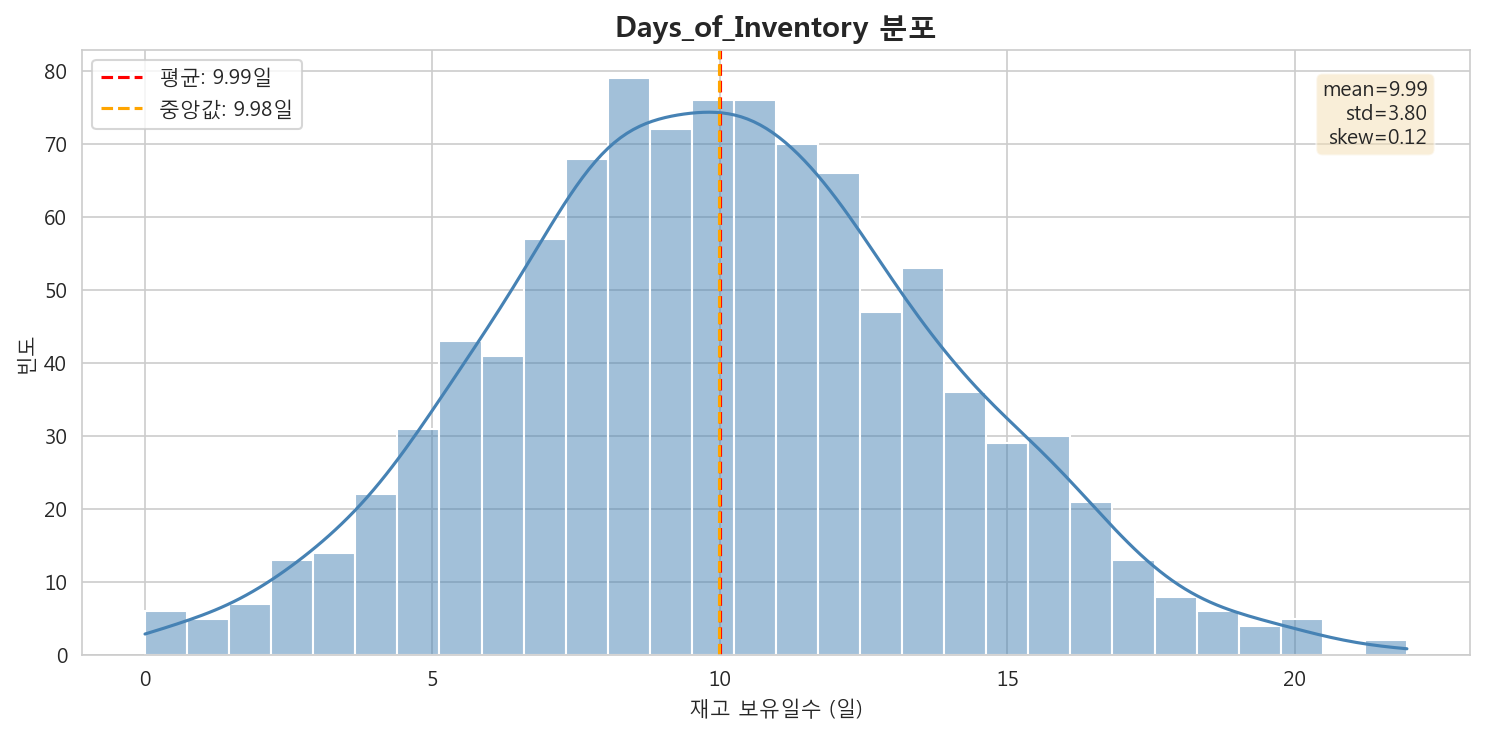

✅ 시각화 #1 저장 완료: doi_distribution_v5_s4.png


In [5]:
# ── 시각화 #1: Days_of_Inventory 분포 (히스토그램 + KDE) ──
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Days_of_Inventory'], bins=30, kde=True, color='steelblue', ax=ax)
ax.axvline(df['Days_of_Inventory'].mean(), color='red', linestyle='--',
           label=f"평균: {df['Days_of_Inventory'].mean():.2f}일")
ax.axvline(df['Days_of_Inventory'].median(), color='orange', linestyle='--',
           label=f"중앙값: {df['Days_of_Inventory'].median():.2f}일")
ax.set_title('Days_of_Inventory 분포', fontsize=14, fontweight='bold')
ax.set_xlabel('재고 보유일수 (일)')
ax.set_ylabel('빈도')
ax.legend()

# 통계 정보 텍스트 박스
stats_text = (f"mean={df['Days_of_Inventory'].mean():.2f}\n"
              f"std={df['Days_of_Inventory'].std():.2f}\n"
              f"skew={df['Days_of_Inventory'].skew():.2f}")
ax.text(0.97, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'doi_distribution_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #1 저장 완료: doi_distribution_v5_s4.png")

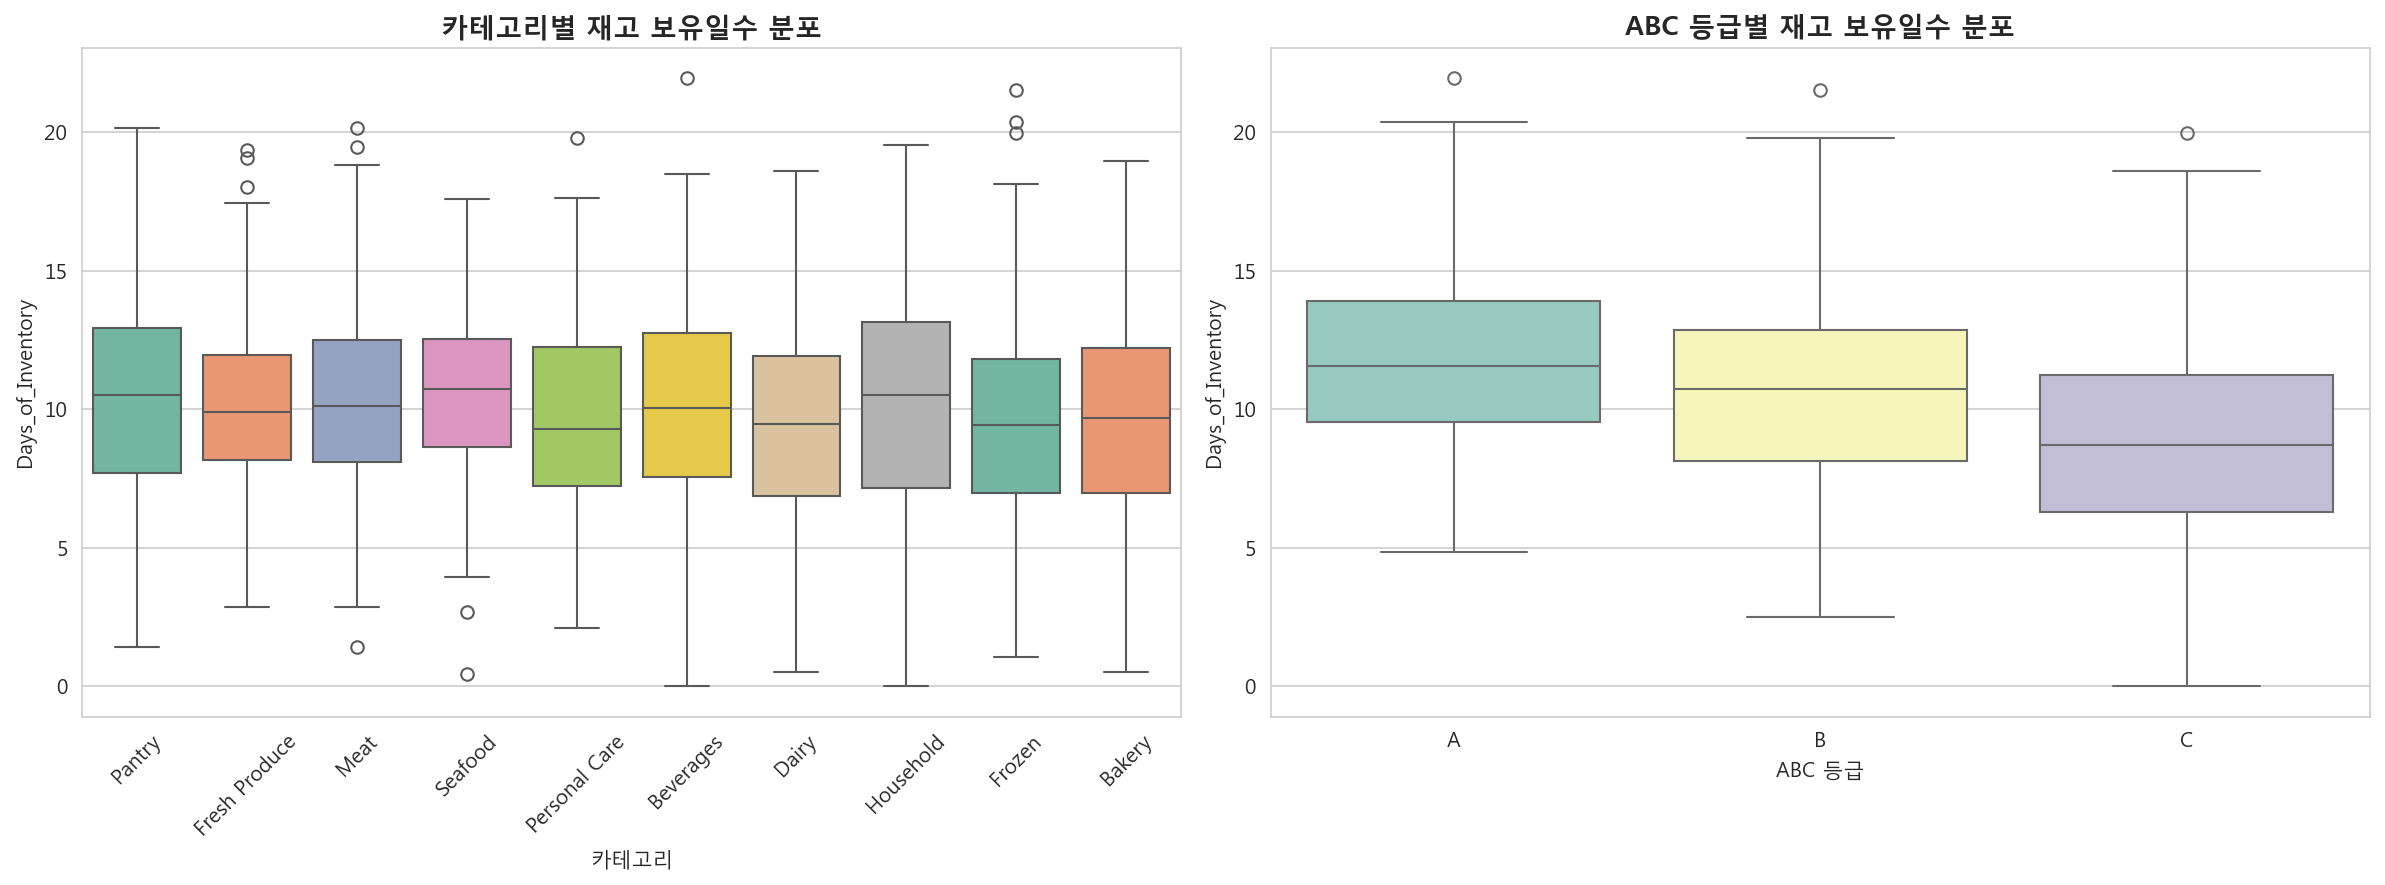

✅ 시각화 #2 저장 완료: category_abc_doi_v5_s4.png


In [6]:
# ── 시각화 #2: 카테고리별·ABC별 보유일수 분포 (boxplot) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 카테고리별
sns.boxplot(data=df, x='Category', y='Days_of_Inventory', ax=axes[0], palette='Set2')
axes[0].set_title('카테고리별 재고 보유일수 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('카테고리')
axes[0].set_ylabel('Days_of_Inventory')
axes[0].tick_params(axis='x', rotation=45)

# ABC 등급별
order_abc = ['A', 'B', 'C']
sns.boxplot(data=df, x='ABC_Class', y='Days_of_Inventory', order=order_abc,
            ax=axes[1], palette='Set3')
axes[1].set_title('ABC 등급별 재고 보유일수 분포', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ABC 등급')
axes[1].set_ylabel('Days_of_Inventory')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'category_abc_doi_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #2 저장 완료: category_abc_doi_v5_s4.png")

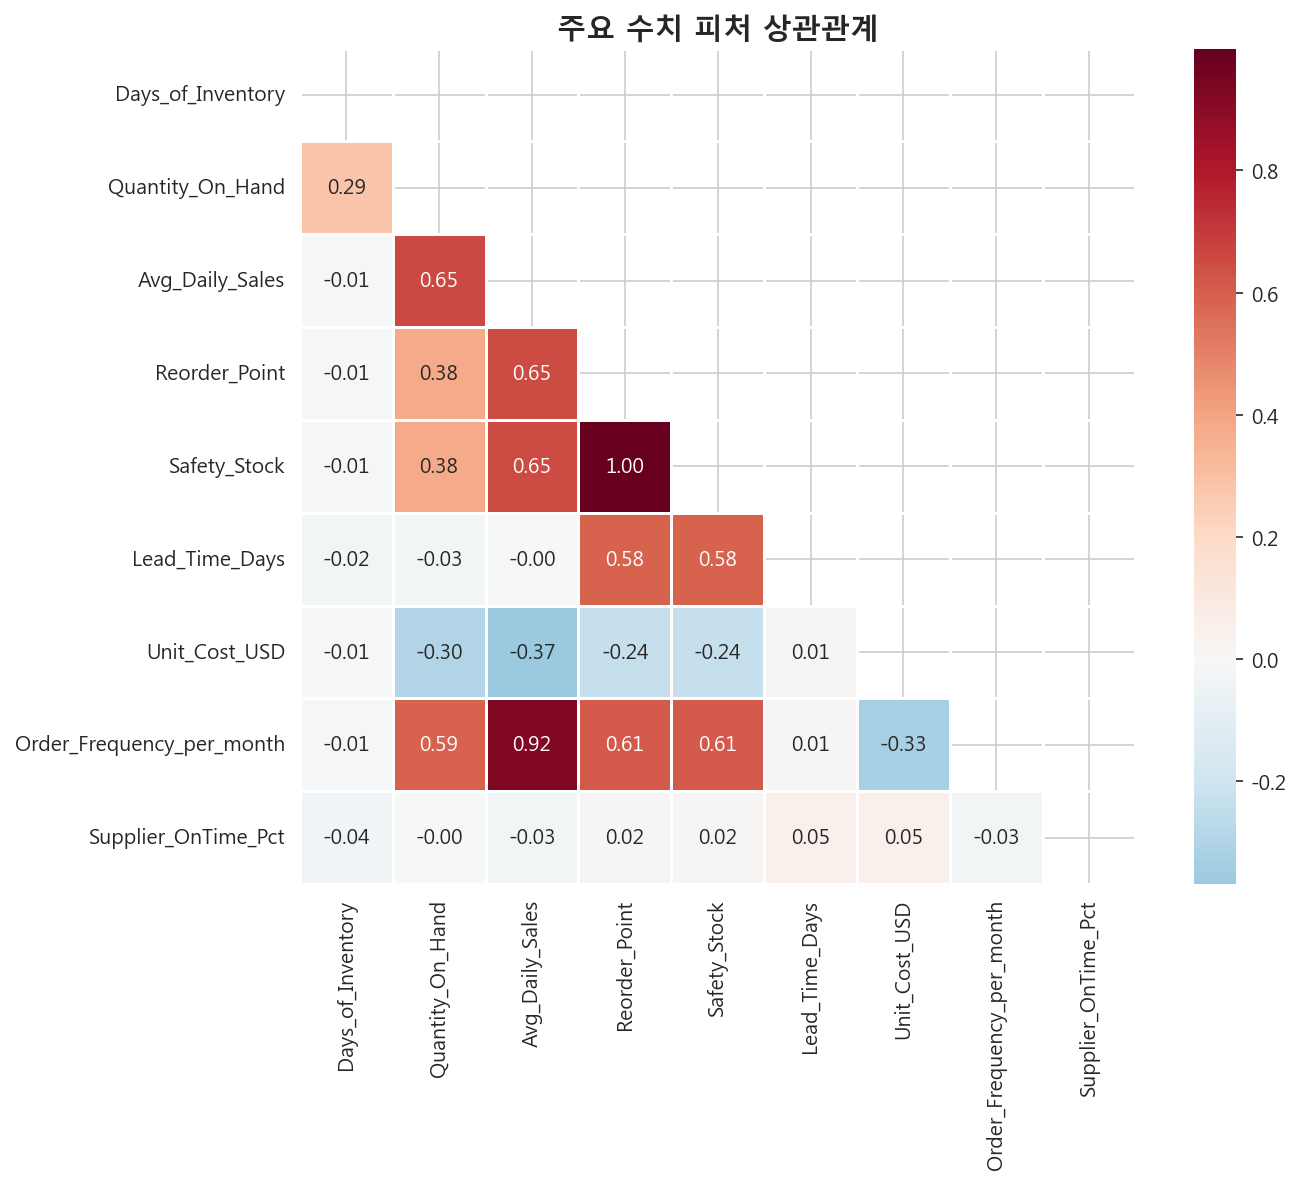

In [7]:
# ── 주요 수치 피처 상관관계 히트맵 ──
corr_cols = ['Days_of_Inventory', 'Quantity_On_Hand', 'Avg_Daily_Sales',
             'Reorder_Point', 'Safety_Stock', 'Lead_Time_Days',
             'Unit_Cost_USD', 'Order_Frequency_per_month', 'Supplier_OnTime_Pct']
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('주요 수치 피처 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. 데이터 누수(Data Leakage) 진단

> ⚠️ **핵심 이슈:** Days_of_Inventory = Quantity_On_Hand / Avg_Daily_Sales
> QOH와 ADS를 Phase A 피처로 사용하면 **타겟을 직접 계산하는 공식**을 학습하게 된다.

In [8]:
# ── DOI ≈ QOH / ADS 검증 ──
ads_nonzero = df['Avg_Daily_Sales'].replace(0, np.nan)
doi_calc = df['Quantity_On_Hand'] / ads_nonzero
doi_actual = df['Days_of_Inventory']

# 일치율 계산 (허용 오차 0.01)
match_mask = (doi_actual > 0) & (doi_calc.notna())
close_match = np.isclose(doi_actual[match_mask], doi_calc[match_mask], rtol=0.01)
match_rate = close_match.sum() / match_mask.sum() * 100

print(f"=== DOI = QOH / ADS 검증 ===")
print(f"일치율 (rtol=0.01): {match_rate:.1f}%")
print(f"검증 건수: {match_mask.sum()} / {len(df)}")

=== DOI = QOH / ADS 검증 ===
일치율 (rtol=0.01): 97.2%
검증 건수: 998 / 1000


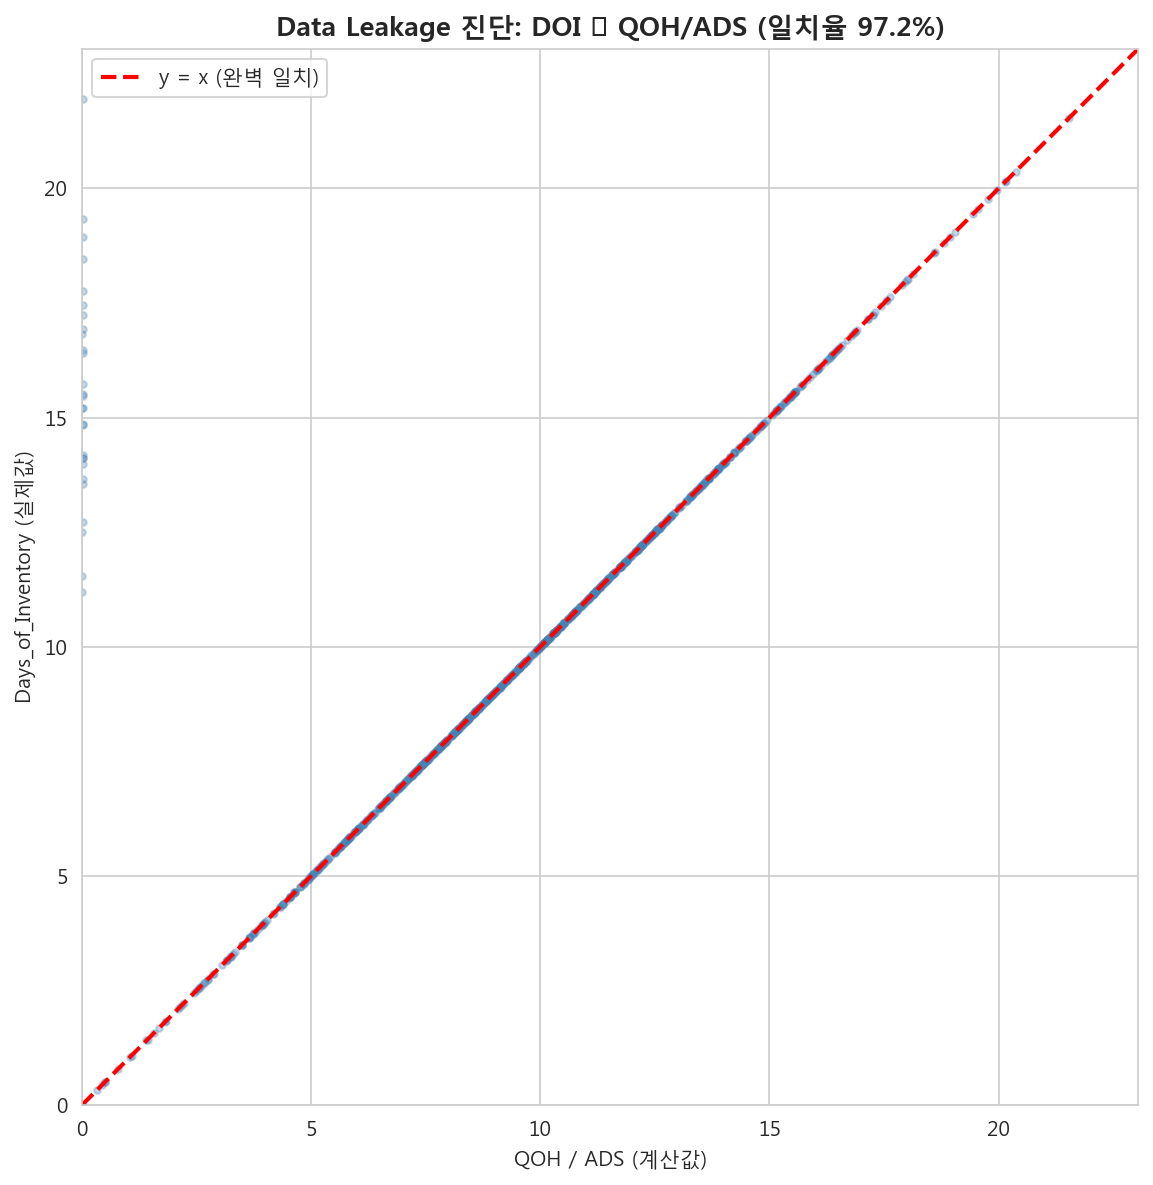

✅ 시각화 #3 저장 완료: leakage_diagnosis_v5_s4.png


In [9]:
# ── 시각화 #3: DOI vs QOH/ADS 일치 검증 산점도 ──
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(doi_calc, doi_actual, alpha=0.3, s=10, color='steelblue')
lims = [0, max(doi_actual.max(), doi_calc.max()) * 1.05]
ax.plot(lims, lims, 'r--', lw=2, label='y = x (완벽 일치)')
ax.set_xlabel('QOH / ADS (계산값)')
ax.set_ylabel('Days_of_Inventory (실제값)')
ax.set_title(f'Data Leakage 진단: DOI ≈ QOH/ADS (일치율 {match_rate:.1f}%)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'leakage_diagnosis_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #3 저장 완료: leakage_diagnosis_v5_s4.png")

In [10]:
# ── Scenario별 R² 비교 (Data Leakage 진단) ──
# ⚠️ RandomForest + 5-Fold CV 사용
#   - DOI = QOH/ADS는 비선형(나눗셈)이므로 트리 모델이 패턴 포착 가능
#   - Train R²는 RF 과적합으로 전부 높게 나오므로, CV R²로 일반화 성능 비교
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

y = df['Days_of_Inventory']

# 수치형 피처 준비
numeric_base = ['Unit_Cost_USD', 'Reorder_Point', 'Safety_Stock',
                'Lead_Time_Days', 'Order_Frequency_per_month', 'Supplier_OnTime_Pct']

# OHE for Category + ABC_Class
cat_dummies = pd.get_dummies(df[['Category', 'ABC_Class']], drop_first=True)

scenarios = {}

# S1: 전체 8개 수치 (QOH+ADS 포함) — Leakage 예상
X_s1 = df[numeric_base + ['Quantity_On_Hand', 'Avg_Daily_Sales']]
rf = RandomForestRegressor(n_estimators=100, random_state=SEED)
scores = cross_val_score(rf, X_s1, y, cv=5, scoring='r2')
scenarios['S1: QOH+ADS 포함'] = scores.mean()

# S2: ADS 제거 (QOH만)
X_s2 = df[numeric_base + ['Quantity_On_Hand']]
rf = RandomForestRegressor(n_estimators=100, random_state=SEED)
scores = cross_val_score(rf, X_s2, y, cv=5, scoring='r2')
scenarios['S2: QOH만'] = scores.mean()

# S3: QOH 제거 (ADS만)
X_s3 = df[numeric_base + ['Avg_Daily_Sales']]
rf = RandomForestRegressor(n_estimators=100, random_state=SEED)
scores = cross_val_score(rf, X_s3, y, cv=5, scoring='r2')
scenarios['S3: ADS만'] = scores.mean()

# S4: QOH+ADS 모두 제거
X_s4 = df[numeric_base]
rf = RandomForestRegressor(n_estimators=100, random_state=SEED)
scores = cross_val_score(rf, X_s4, y, cv=5, scoring='r2')
scenarios['S4: QOH+ADS 제거'] = scores.mean()

# S5: S4 + Category + ABC (최종 채택 피처셋)
X_s5 = pd.concat([df[numeric_base], cat_dummies], axis=1)
rf = RandomForestRegressor(n_estimators=100, random_state=SEED)
scores = cross_val_score(rf, X_s5, y, cv=5, scoring='r2')
scenarios['S5: S4+Cat+ABC'] = scores.mean()

print("=== Scenario별 5-Fold CV R² 비교 (RandomForest — Leakage 진단) ===")
for name, r2 in scenarios.items():
    if r2 > 0.8:
        marker = " 🔴 Leakage!"
    elif 'S5' in name or 'S4' in name:
        marker = " ✅ 안전"
    else:
        marker = ""
    print(f"  {name}: CV R² = {r2:.4f}{marker}")

print("\n▸ S1(QOH+ADS 포함) CV R²가 매우 높으면 → DOI = QOH/ADS 관계에 의한 Data Leakage")
print("▸ S4/S5(QOH+ADS 제거) CV R²가 크게 하락하면 → Leakage 제거 확인")
print("▸ Phase A에서는 S5 기반(QOH, ADS 제외) 피처셋으로 학습 진행")

=== Scenario별 5-Fold CV R² 비교 (RandomForest — Leakage 진단) ===
  S1: QOH+ADS 포함: CV R² = 0.9086 🔴 Leakage!
  S2: QOH만: CV R² = 0.5933
  S3: ADS만: CV R² = -0.0840
  S4: QOH+ADS 제거: CV R² = -0.0710 ✅ 안전
  S5: S4+Cat+ABC: CV R² = 0.2497 ✅ 안전

▸ S1(QOH+ADS 포함) CV R²가 매우 높으면 → DOI = QOH/ADS 관계에 의한 Data Leakage
▸ S4/S5(QOH+ADS 제거) CV R²가 크게 하락하면 → Leakage 제거 확인
▸ Phase A에서는 S5 기반(QOH, ADS 제외) 피처셋으로 학습 진행


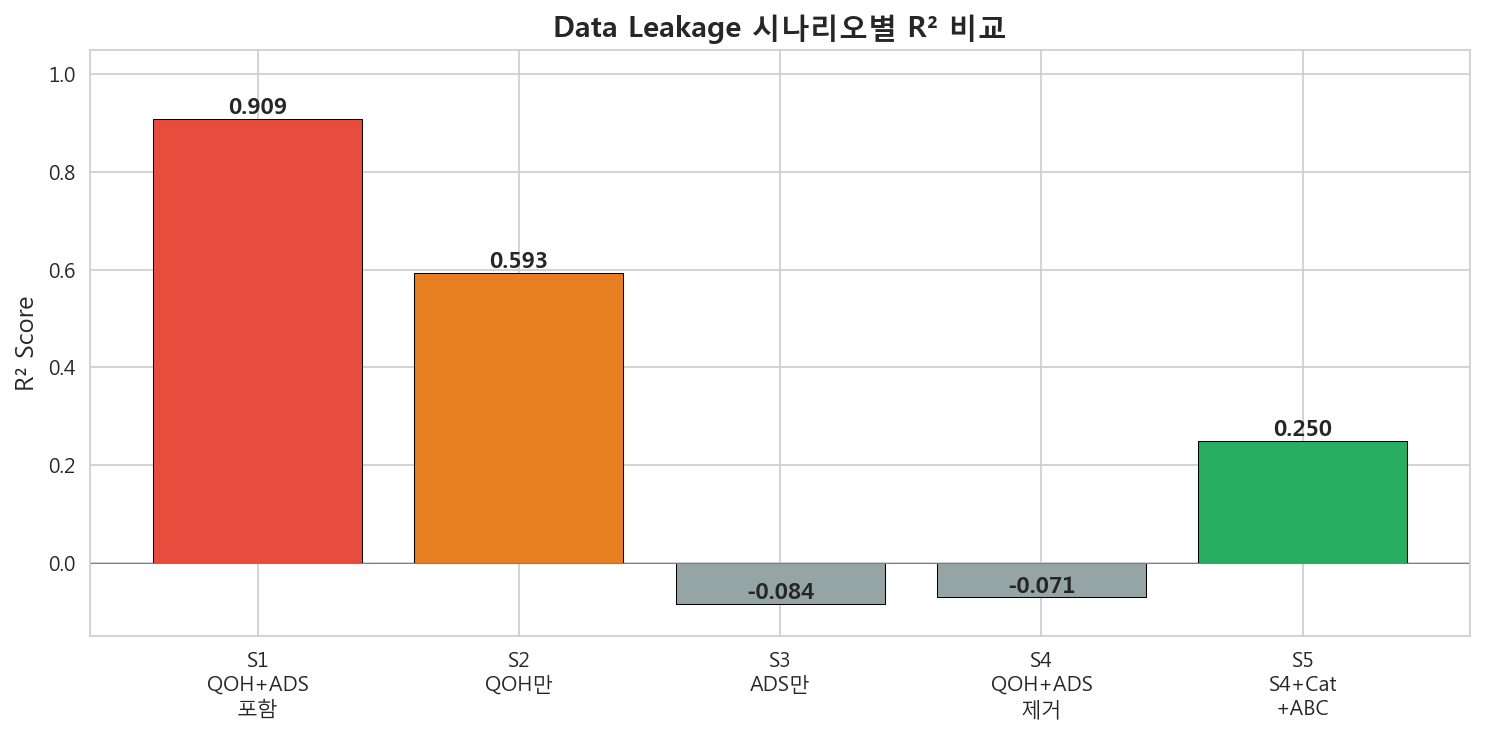

✅ 시각화 #4 저장 완료: leakage_scenarios_v5_s4.png


In [11]:
# ── 시각화 #4: Scenario별 R² 비교 바 차트 ──
fig, ax = plt.subplots(figsize=(10, 5))
names = list(scenarios.keys())
values = list(scenarios.values())
colors = ['#e74c3c', '#e67e22', '#95a5a6', '#95a5a6', '#27ae60']

bars = ax.bar(range(len(names)), values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(['S1\nQOH+ADS\n포함', 'S2\nQOH만', 'S3\nADS만',
                     'S4\nQOH+ADS\n제거', 'S5\nS4+Cat\n+ABC'],
                    fontsize=10)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Data Leakage 시나리오별 R² 비교', fontsize=14, fontweight='bold')

# 값 표시
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_ylim(-0.15, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'leakage_scenarios_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #4 저장 완료: leakage_scenarios_v5_s4.png")

### 3.1 Data Leakage 진단 결론

> **위 Scenario 비교에서 핵심은 QOH/ADS 포함 여부에 따른 CV R² 격차이다.**

| 시나리오 | 포함 피처 | 해석 |
|----------|----------|------|
| S1 | QOH+ADS 포함 | 🔴 Leakage — DOI = QOH/ADS 나눗셈 공식을 학습 |
| S2 | QOH만 | 🟡 부분 Leakage — 분자(QOH) 정보 사용 |
| S3 | ADS만 | 🟡 부분 Leakage — 분모(ADS) 정보 사용 |
| S4 | QOH+ADS 모두 제거 | ✅ 누수 제거 — 순수 독립변수만 사용 |
| **S5** | **S4 + Category + ABC** | **✅ 채택 — 범주형 변수가 DOI 설명에 추가 기여** |

**패턴 해석:**
- S1 CV R²가 S4/S5 대비 **현저히 높으면** → QOH+ADS에 의한 Data Leakage 확인
- S4/S5의 CV R²가 비교적 낮으면 → 누수 없이 순수 예측력만 반영
- S5 > S4 차이가 있으면 → Category/ABC 변수의 추가 설명력 존재

> **결론:** Phase A에서 QOH와 ADS를 반드시 제거하고, Category + ABC_Class 인코딩으로 보완한다.
> Phase A의 가치는 R² 절대값보다 **Feature Importance 해석과 군집 연결**에 있다.

## 4. 파생변수 엔지니어링

> 모든 파생변수는 원본 37열의 실측치에서 산출한다. [V5] 소주제 1 연계 피처 2개 추가. 보충 데이터로 임의 값을 만들지 않는다.


In [12]:
# ── 발주 전략 파생변수 (10개) [V5 업데이트] ──

# 1. Dynamic_ROP: 수요 기반 동적 재주문점
df['Dynamic_ROP'] = df['Avg_Daily_Sales'] * df['Lead_Time_Days'] + df['Safety_Stock']

# 2. ROP_Gap: 설정된 재주문점과 동적 재주문점의 차이
df['ROP_Gap'] = df['Reorder_Point'] - df['Dynamic_ROP']

# 3. Stock_Coverage_Days: 안전재고 초과분으로 버틸 수 있는 일수
ads_safe = df['Avg_Daily_Sales'].replace(0, np.nan)
df['Stock_Coverage_Days'] = (
    (df['Quantity_On_Hand'] - df['Safety_Stock']) / ads_safe
).fillna(0).clip(-100, 365)

# 4. Demand_Variability: 카테고리 내 수요 변동계수 (CV)
#    ⚠️ 한계: 10개 카테고리 CV가 0.52~0.56으로 균질 → 변별력 낮음
cat_stats = df.groupby('Category')['Avg_Daily_Sales'].agg(['mean', 'std'])
cat_stats['CV'] = cat_stats['std'] / cat_stats['mean']
df['Demand_Variability'] = df['Category'].map(cat_stats['CV'])

# 5. EOQ: 경제적 발주량 √(2×D×S/H)
df['Annual_Demand'] = df['Avg_Daily_Sales'] * 365
df['Holding_Cost'] = df['Unit_Cost_USD'] * HOLDING_RATE
df['EOQ'] = np.sqrt(
    2 * df['Annual_Demand'] * ORDERING_COST /
    df['Holding_Cost'].replace(0, 1)
)

# 6. Reorder_Urgency: 즉시 발주 필요 여부 (이진)
df['Reorder_Urgency'] = (df['Quantity_On_Hand'] <= df['Reorder_Point']).astype(int)

# 7. Supply_Risk: 공급 리스크 지수
df['Supply_Risk'] = df['Lead_Time_Days'] * (1 - df['Supplier_OnTime_Pct'] / 100)

# 8. Order_Efficiency: 현재 재고 / EOQ 비율
df['Order_Efficiency'] = (
    df['Quantity_On_Hand'] / df['EOQ'].replace(0, np.nan)
).fillna(1).clip(0, 10)

# ── [V5 추가] 소주제 1 연계 파생변수 ──

# 9. Available_Stock: 재주문점 대비 현재 재고 여유분
#    = QOH - Reorder_Point
#    음수 → 재고 부족 (즉시 발주 필요), 양수 → 재고 여유
#    ※ 소주제 1 LightGBM Top-4 피처 (중요도 613점)
df['Available_Stock'] = df['Quantity_On_Hand'] - df['Reorder_Point']

# 10. RP_SS_Ratio: 재주문점 / 안전재고 비율
#     높을수록 안전재고 대비 재주문점을 공격적으로 설정
#     ※ 소주제 1 상관분석: RP↔SS r=0.7645
df['RP_SS_Ratio'] = (
    df['Reorder_Point'] / df['Safety_Stock'].replace(0, np.nan)
).fillna(0).clip(0, 10)

# 검증
derived_features = ['Dynamic_ROP', 'ROP_Gap', 'Stock_Coverage_Days',
                    'Demand_Variability', 'EOQ', 'Reorder_Urgency',
                    'Supply_Risk', 'Order_Efficiency',
                    'Available_Stock', 'RP_SS_Ratio']
print("=== 파생변수 요약 통계 (10개) ===")
print(df[derived_features].describe().round(2))

# [V5] Demand_Variability 한계 확인
print(f"\n⚠️ Demand_Variability 범위: {df['Demand_Variability'].min():.4f} ~ {df['Demand_Variability'].max():.4f}")
print(f"   → 0.52~0.56 수준으로 변별력 매우 낮음")
print(f"\n✅ Available_Stock 범위: {df['Available_Stock'].min():.0f} ~ {df['Available_Stock'].max():.0f}")
print(f"   → 넓은 분산으로 군집 분리 기여 기대")
print(f"\n✅ RP_SS_Ratio 범위: {df['RP_SS_Ratio'].min():.2f} ~ {df['RP_SS_Ratio'].max():.2f}")
print(f"   → 평균 {df['RP_SS_Ratio'].mean():.2f}")


=== 파생변수 요약 통계 (10개) ===
       Dynamic_ROP  ROP_Gap  Stock_Coverage_Days  Demand_Variability      EOQ  \
count      1000.00  1000.00              1000.00             1000.00  1000.00   
mean        165.42    -0.00                 7.11                0.54  1184.48   
std         197.97     0.29                 4.31                0.01   975.86   
min           3.29    -0.50                -7.10                0.52   112.05   
25%          47.74    -0.25                 4.45                0.52   510.17   
50%          99.72    -0.01                 7.23                0.54   871.60   
75%         202.89     0.24                 9.98                0.55  1577.77   
max        1870.14     0.50                20.83                0.56  6649.46   

       Reorder_Urgency  Supply_Risk  Order_Efficiency  Available_Stock  \
count          1000.00      1000.00           1000.00          1000.00   
mean              0.27         0.61              0.22            66.14   
std               0.44 

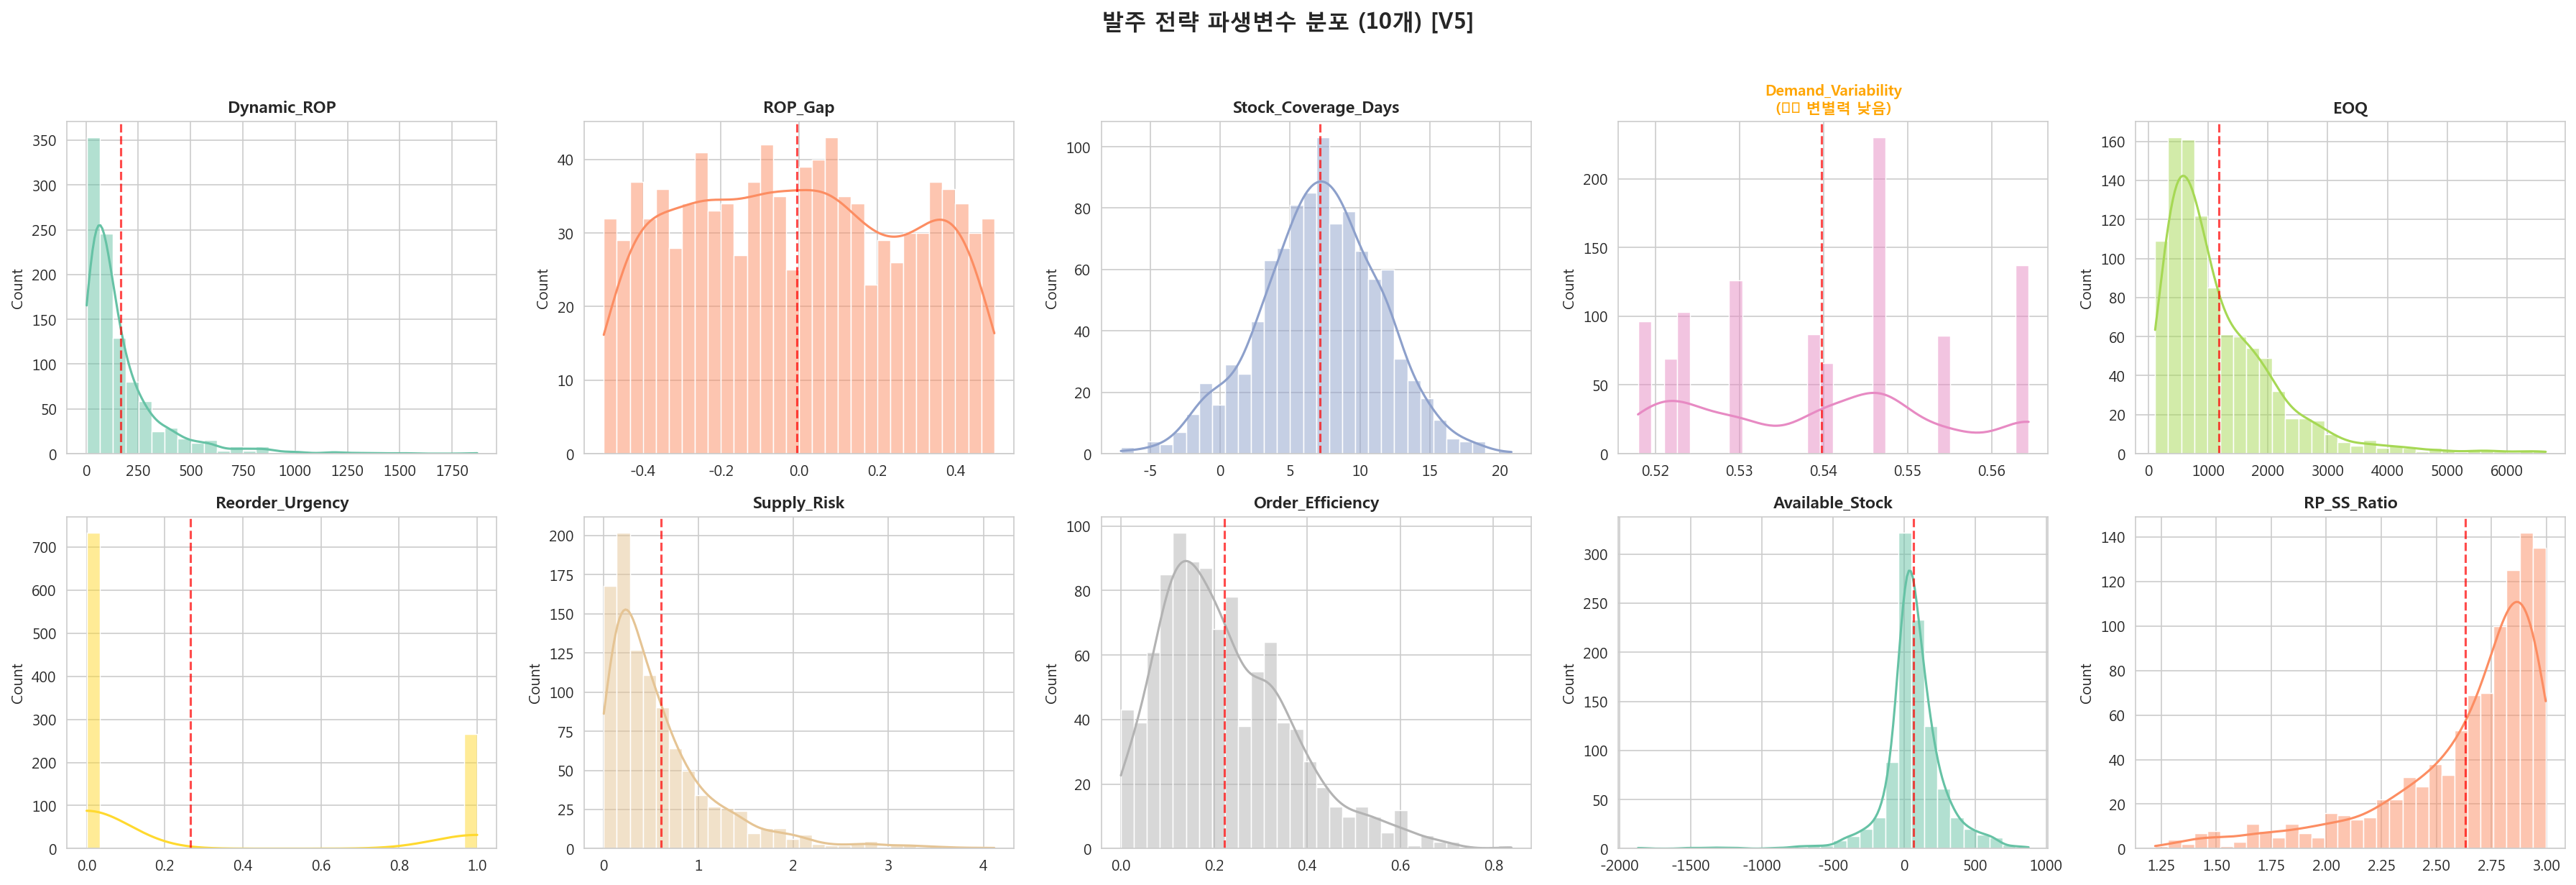

✅ 시각화 #5 저장 완료: derived_features_dist_v5_s4.png


In [13]:
# ── 시각화 #5: 파생변수 분포 요약 (2×5 서브플롯) [V5] ──
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

for i, feat in enumerate(derived_features):
    ax = axes[i]
    sns.histplot(df[feat], bins=30, kde=True, ax=ax, color=sns.color_palette('Set2')[i % 8])
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    mean_val = df[feat].mean()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.7)
    # [V5] Demand_Variability에 한계 표시
    if feat == 'Demand_Variability':
        ax.set_title('Demand_Variability\n(⚠️ 변별력 낮음)', fontsize=10, fontweight='bold', color='orange')

plt.suptitle('발주 전략 파생변수 분포 (10개) [V5]', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'derived_features_dist_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #5 저장 완료: derived_features_dist_v5_s4.png")


In [14]:
# ── One-Hot 인코딩 ──
df_encoded = pd.get_dummies(df, columns=['Category', 'ABC_Class'], drop_first=True)
cat_ohe_cols = [c for c in df_encoded.columns if c.startswith('Category_') or c.startswith('ABC_Class_')]
print(f"인코딩 후 Shape: {df_encoded.shape}")
print(f"OHE 컬럼 ({len(cat_ohe_cols)}개): {cat_ohe_cols}")

인코딩 후 Shape: (1000, 58)
OHE 컬럼 (11개): ['Category_Beverages', 'Category_Dairy', 'Category_Fresh Produce', 'Category_Frozen', 'Category_Household', 'Category_Meat', 'Category_Pantry', 'Category_Personal Care', 'Category_Seafood', 'ABC_Class_B', 'ABC_Class_C']


---
## ═══ Phase A: 재고 보유일수 예측 (Regression) ═══

> Phase A의 핵심 가치는 R² 높이기가 아니라, **어떤 변수가 DOI에 영향을 주는지** Feature Importance로 해석하는 것

## 5. Phase A — 피처/타겟 분리 & 전처리

In [15]:
# ── Baseline 피처셋 (17개): 수치 6개 + OHE 11개 ──
baseline_numeric_A = [
    'Unit_Cost_USD', 'Reorder_Point', 'Safety_Stock',
    'Lead_Time_Days', 'Order_Frequency_per_month', 'Supplier_OnTime_Pct'
]

# ── Enhanced 피처셋 (최대 22개): 수치 11개 + OHE 11개 [V5] ──
enhanced_numeric_A = baseline_numeric_A + [
    'Demand_Variability',   # 카테고리별 수요 변동성 (⚠️ 변별력 낮음)
    'Supply_Risk',          # 공급 리스크 지수
    'EOQ',                  # 경제적 발주량
    'Reorder_Urgency',      # 즉시 발주 필요 여부
    'RP_SS_Ratio',          # [V5] 재주문점/안전재고 비율 — Leakage 없음
]

# 타겟
y = df_encoded['Days_of_Inventory']

# Baseline X
X_baseline = df_encoded[baseline_numeric_A + cat_ohe_cols]
# Enhanced X
X_enhanced = df_encoded[enhanced_numeric_A + cat_ohe_cols]

print(f"Baseline 피처: {X_baseline.shape[1]}개")
print(f"Enhanced 피처: {X_enhanced.shape[1]}개 [V5: RP_SS_Ratio 추가]")
print(f"타겟 (DOI): mean={y.mean():.2f}, std={y.std():.2f}")


Baseline 피처: 17개
Enhanced 피처: 22개 [V5: RP_SS_Ratio 추가]
타겟 (DOI): mean=9.99, std=3.80


In [16]:
# ── Train/Test Split ──
X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=SEED)
X_train_e, X_test_e, _, _ = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=SEED)

# ── StandardScaler ──
scaler_baseline = StandardScaler()
X_train_b_sc = scaler_baseline.fit_transform(X_train_b)
X_test_b_sc = scaler_baseline.transform(X_test_b)

scaler_enhanced = StandardScaler()
X_train_e_sc = scaler_enhanced.fit_transform(X_train_e)
X_test_e_sc = scaler_enhanced.transform(X_test_e)

print(f"Train: {X_train_b_sc.shape[0]}행, Test: {X_test_b_sc.shape[0]}행")

Train: 800행, Test: 200행


## 6. Phase A — 모델 학습 & 평가

In [17]:
# ── 6.1 Baseline & Enhanced 학습 (Default 파라미터) ──
models_def = {
    'LR': LinearRegression(),
    'RF': RandomForestRegressor(n_estimators=100, random_state=SEED),
    'XGB': XGBRegressor(objective='reg:squarederror', random_state=SEED, verbosity=0),
}

results_A = {}

for set_name, X_tr, X_te in [('Baseline', X_train_b_sc, X_test_b_sc),
                               ('Enhanced', X_train_e_sc, X_test_e_sc)]:
    print(f"\n=== {set_name} 피처셋 (Default) ===")
    for m_name, model in models_def.items():
        # 매번 새 인스턴스
        if m_name == 'LR':
            m = LinearRegression()
        elif m_name == 'RF':
            m = RandomForestRegressor(n_estimators=100, random_state=SEED)
        else:
            m = XGBRegressor(objective='reg:squarederror', random_state=SEED, verbosity=0)

        m.fit(X_tr, y_train)
        y_pred = m.predict(X_te)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        results_A[f'{set_name}_{m_name}_default'] = {
            'R2': r2, 'RMSE': rmse, 'MAE': mae, 'model': m
        }
        print(f"  {m_name}: R²={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}")


=== Baseline 피처셋 (Default) ===
  LR: R²=0.1462, RMSE=3.70, MAE=3.05
  RF: R²=0.2503, RMSE=3.46, MAE=2.82


  XGB: R²=0.2001, RMSE=3.58, MAE=2.87

=== Enhanced 피처셋 (Default) ===
  LR: R²=0.3260, RMSE=3.28, MAE=2.63


  RF: R²=0.3817, RMSE=3.14, MAE=2.59
  XGB: R²=0.4397, RMSE=2.99, MAE=2.43


In [18]:
# ── 6.2 5-Fold Cross-Validation 과적합 진단 ──
cv_results = {}
for set_name, X_full_sc, X_tr, X_te in [
    ('Baseline', scaler_baseline.transform(X_baseline), X_train_b_sc, X_test_b_sc),
    ('Enhanced', scaler_enhanced.transform(X_enhanced), X_train_e_sc, X_test_e_sc)
]:
    print(f"\n=== {set_name} — 5-Fold Cross-Validation ===")
    for m_name in ['LR', 'RF', 'XGB']:
        if m_name == 'LR':
            m = LinearRegression()
        elif m_name == 'RF':
            m = RandomForestRegressor(n_estimators=100, random_state=SEED)
        else:
            m = XGBRegressor(objective='reg:squarederror', random_state=SEED, verbosity=0)

        cv_scores = cross_val_score(m, X_full_sc, y, cv=5, scoring='r2')
        m.fit(X_tr, y_train)
        train_r2 = m.score(X_tr, y_train)
        test_r2 = m.score(X_te, y_test)
        gap = train_r2 - test_r2

        cv_results[f'{set_name}_{m_name}'] = {
            'CV_mean': cv_scores.mean(), 'CV_std': cv_scores.std(),
            'Train_R2': train_r2, 'Test_R2': test_r2, 'Gap': gap
        }
        warn = " ⚠️ 과적합 의심" if gap > 0.15 else ""
        print(f"  {m_name}: CV R²={cv_scores.mean():.4f}±{cv_scores.std():.4f}, "
              f"Train={train_r2:.4f}, Test={test_r2:.4f}, Gap={gap:.4f}{warn}")


=== Baseline — 5-Fold Cross-Validation ===
  LR: CV R²=0.1802±0.0342, Train=0.2211, Test=0.1462, Gap=0.0748


  RF: CV R²=0.2497±0.0567, Train=0.8965, Test=0.2503, Gap=0.6462 ⚠️ 과적합 의심


  XGB: CV R²=0.1471±0.0632, Train=0.9962, Test=0.2001, Gap=0.7961 ⚠️ 과적합 의심

=== Enhanced — 5-Fold Cross-Validation ===
  LR: CV R²=0.3377±0.0428, Train=0.3731, Test=0.3260, Gap=0.0470


  RF: CV R²=0.4005±0.0519, Train=0.9139, Test=0.3817, Gap=0.5322 ⚠️ 과적합 의심


  XGB: CV R²=0.3371±0.0342, Train=0.9992, Test=0.4397, Gap=0.5594 ⚠️ 과적합 의심


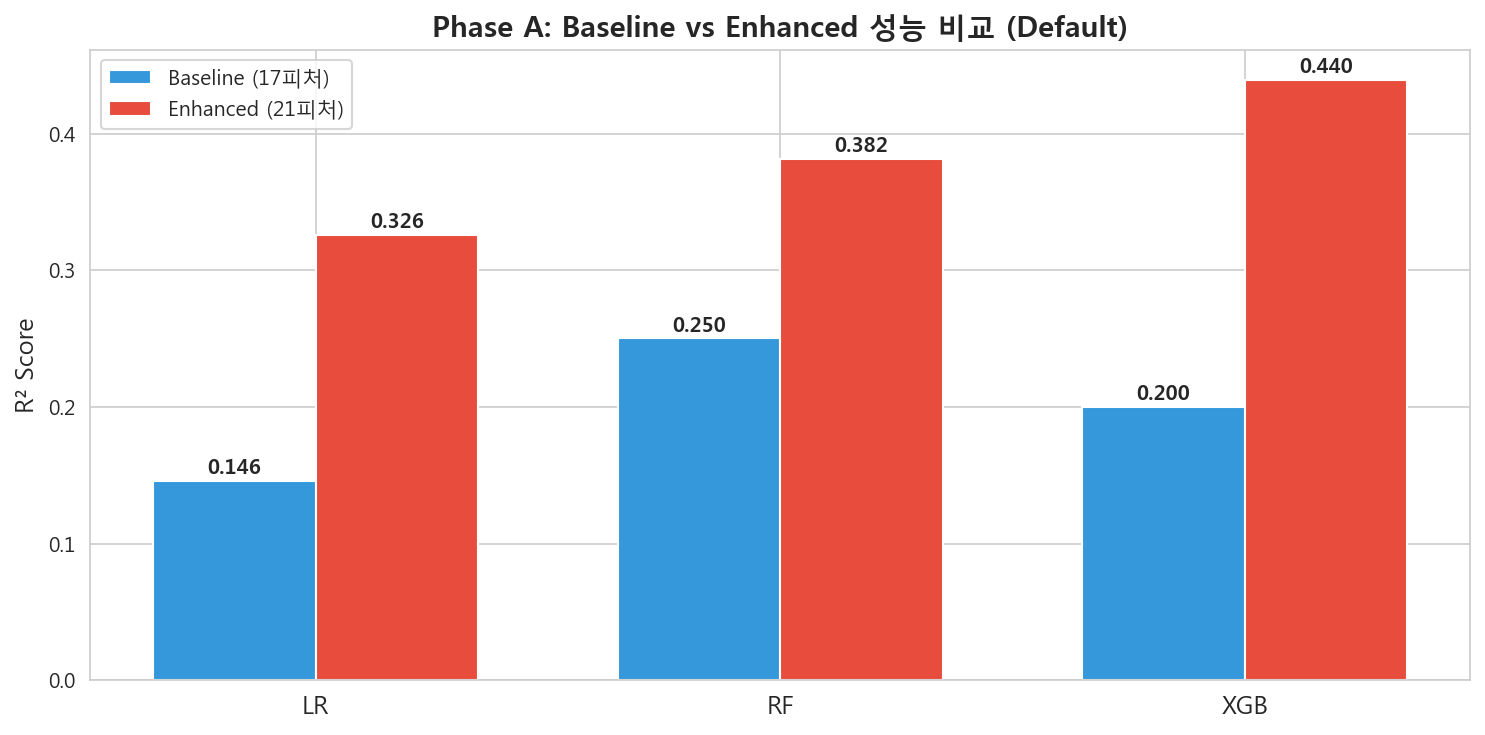

✅ 시각화 #6 저장 완료: phaseA_baseline_vs_enhanced_v5_s4.png


In [19]:
# ── 시각화 #6: Baseline vs Enhanced R² 비교 (그룹 막대) ──
fig, ax = plt.subplots(figsize=(10, 5))
model_names = ['LR', 'RF', 'XGB']
x = np.arange(len(model_names))
width = 0.35

baseline_r2 = [results_A[f'Baseline_{m}_default']['R2'] for m in model_names]
enhanced_r2 = [results_A[f'Enhanced_{m}_default']['R2'] for m in model_names]

bars1 = ax.bar(x - width/2, baseline_r2, width, label='Baseline (17피처)', color='#3498db')
bars2 = ax.bar(x + width/2, enhanced_r2, width, label='Enhanced (21피처)', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Phase A: Baseline vs Enhanced 성능 비교 (Default)', fontsize=14, fontweight='bold')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseA_baseline_vs_enhanced_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #6 저장 완료: phaseA_baseline_vs_enhanced_v5_s4.png")

In [20]:
# ── 6.3 GridSearchCV 하이퍼파라미터 튜닝 (Enhanced 기준) ──
print("=== GridSearchCV 튜닝 (Enhanced 피처셋) ===")

# RF 튜닝
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [2, 5, 10]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    rf_params, cv=5, scoring='r2', n_jobs=-1
)
rf_grid.fit(X_train_e_sc, y_train)
print(f"RF 최적 파라미터: {rf_grid.best_params_}")
print(f"RF 최적 CV R²: {rf_grid.best_score_:.4f}")
rf_tuned = rf_grid.best_estimator_

# XGB 튜닝
xgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'reg_alpha': [0, 0.5, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0]
}
xgb_grid = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=SEED, verbosity=0),
    xgb_params, cv=5, scoring='r2', n_jobs=-1
)
xgb_grid.fit(X_train_e_sc, y_train)
print(f"\nXGB 최적 파라미터: {xgb_grid.best_params_}")
print(f"XGB 최적 CV R²: {xgb_grid.best_score_:.4f}")
xgb_tuned = xgb_grid.best_estimator_

# Tuned 결과 저장
for m_name, m in [('RF', rf_tuned), ('XGB', xgb_tuned)]:
    y_pred = m.predict(X_test_e_sc)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results_A[f'Enhanced_{m_name}_tuned'] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'model': m}
    print(f"\n{m_name} Tuned — Test R²={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}")

=== GridSearchCV 튜닝 (Enhanced 피처셋) ===


RF 최적 파라미터: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 300}
RF 최적 CV R²: 0.3639



XGB 최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 1.0, 'reg_lambda': 10.0}
XGB 최적 CV R²: 0.3741

RF Tuned — Test R²=0.3710, RMSE=3.17, MAE=2.60

XGB Tuned — Test R²=0.4218, RMSE=3.04, MAE=2.45


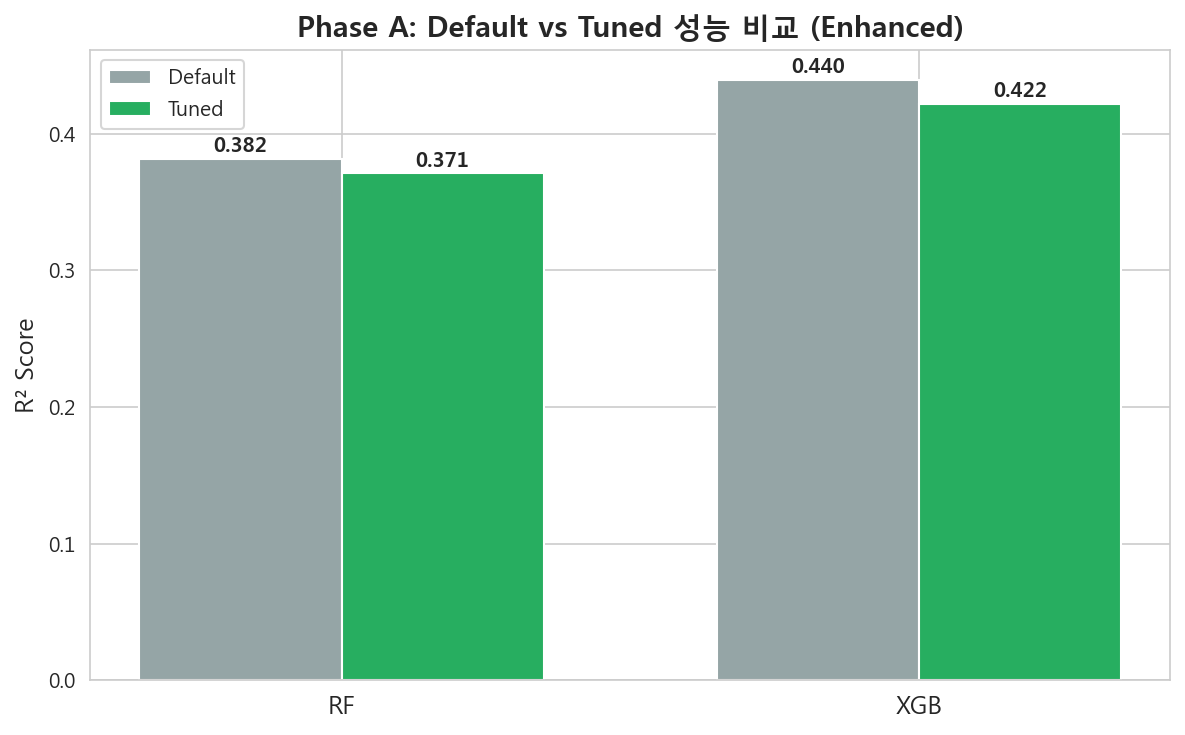

✅ 시각화 #7 저장 완료: phaseA_default_vs_tuned_v5_s4.png


In [21]:
# ── 시각화 #7: Default vs Tuned R² 비교 ──
fig, ax = plt.subplots(figsize=(8, 5))
tunable = ['RF', 'XGB']
x = np.arange(len(tunable))
width = 0.35

default_r2 = [results_A[f'Enhanced_{m}_default']['R2'] for m in tunable]
tuned_r2 = [results_A[f'Enhanced_{m}_tuned']['R2'] for m in tunable]

bars1 = ax.bar(x - width/2, default_r2, width, label='Default', color='#95a5a6')
bars2 = ax.bar(x + width/2, tuned_r2, width, label='Tuned', color='#27ae60')

ax.set_xticks(x)
ax.set_xticklabels(tunable, fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Phase A: Default vs Tuned 성능 비교 (Enhanced)', fontsize=14, fontweight='bold')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseA_default_vs_tuned_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #7 저장 완료: phaseA_default_vs_tuned_v5_s4.png")

Phase A 최적 모델: Enhanced_XGB_tuned (R²=0.4218)


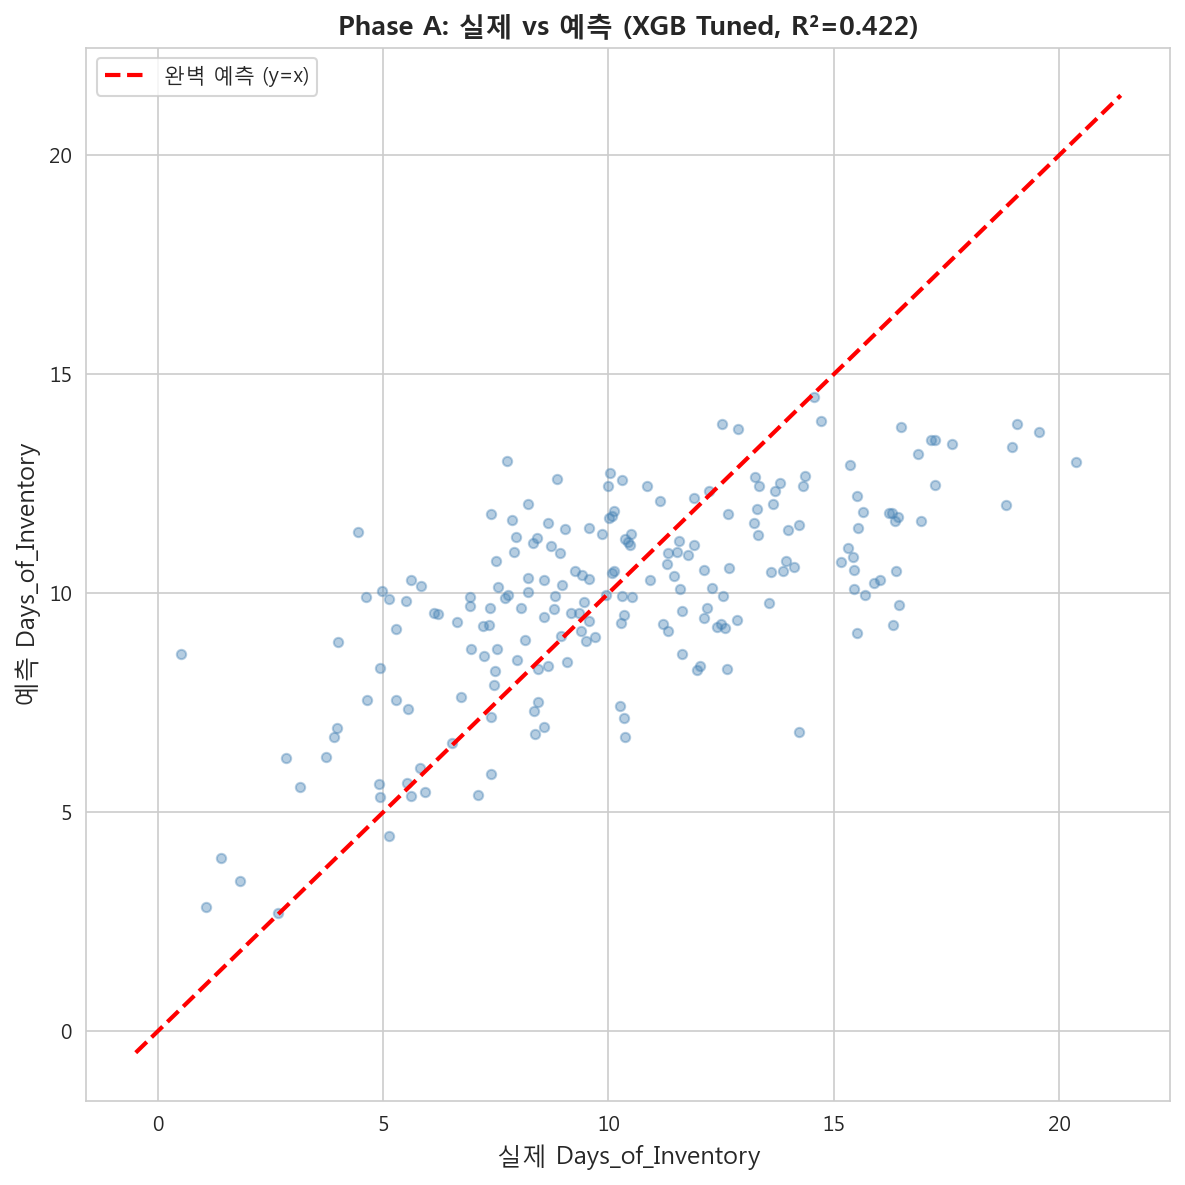

✅ 시각화 #8 저장 완료: phaseA_actual_vs_predicted_v5_s4.png


In [22]:
# ── 최적 모델 선택 ──
# Enhanced Tuned 중 R²가 높은 모델 선택
best_key = max([k for k in results_A if 'Enhanced' in k and 'tuned' in k],
               key=lambda k: results_A[k]['R2'])
best_model_enhanced = results_A[best_key]['model']
best_model_name = best_key.split('_')[1]
print(f"Phase A 최적 모델: {best_key} (R²={results_A[best_key]['R2']:.4f})")

# ── 시각화 #8: 실제 vs 예측 산점도 ──
y_pred_best = best_model_enhanced.predict(X_test_e_sc)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_best, alpha=0.4, s=20, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()) - 1,
        max(y_test.max(), y_pred_best.max()) + 1]
ax.plot(lims, lims, 'r--', lw=2, label='완벽 예측 (y=x)')
ax.set_xlabel('실제 Days_of_Inventory', fontsize=12)
ax.set_ylabel('예측 Days_of_Inventory', fontsize=12)
ax.set_title(f'Phase A: 실제 vs 예측 ({best_model_name} Tuned, R²={results_A[best_key]["R2"]:.3f})',
             fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseA_actual_vs_predicted_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #8 저장 완료: phaseA_actual_vs_predicted_v5_s4.png")

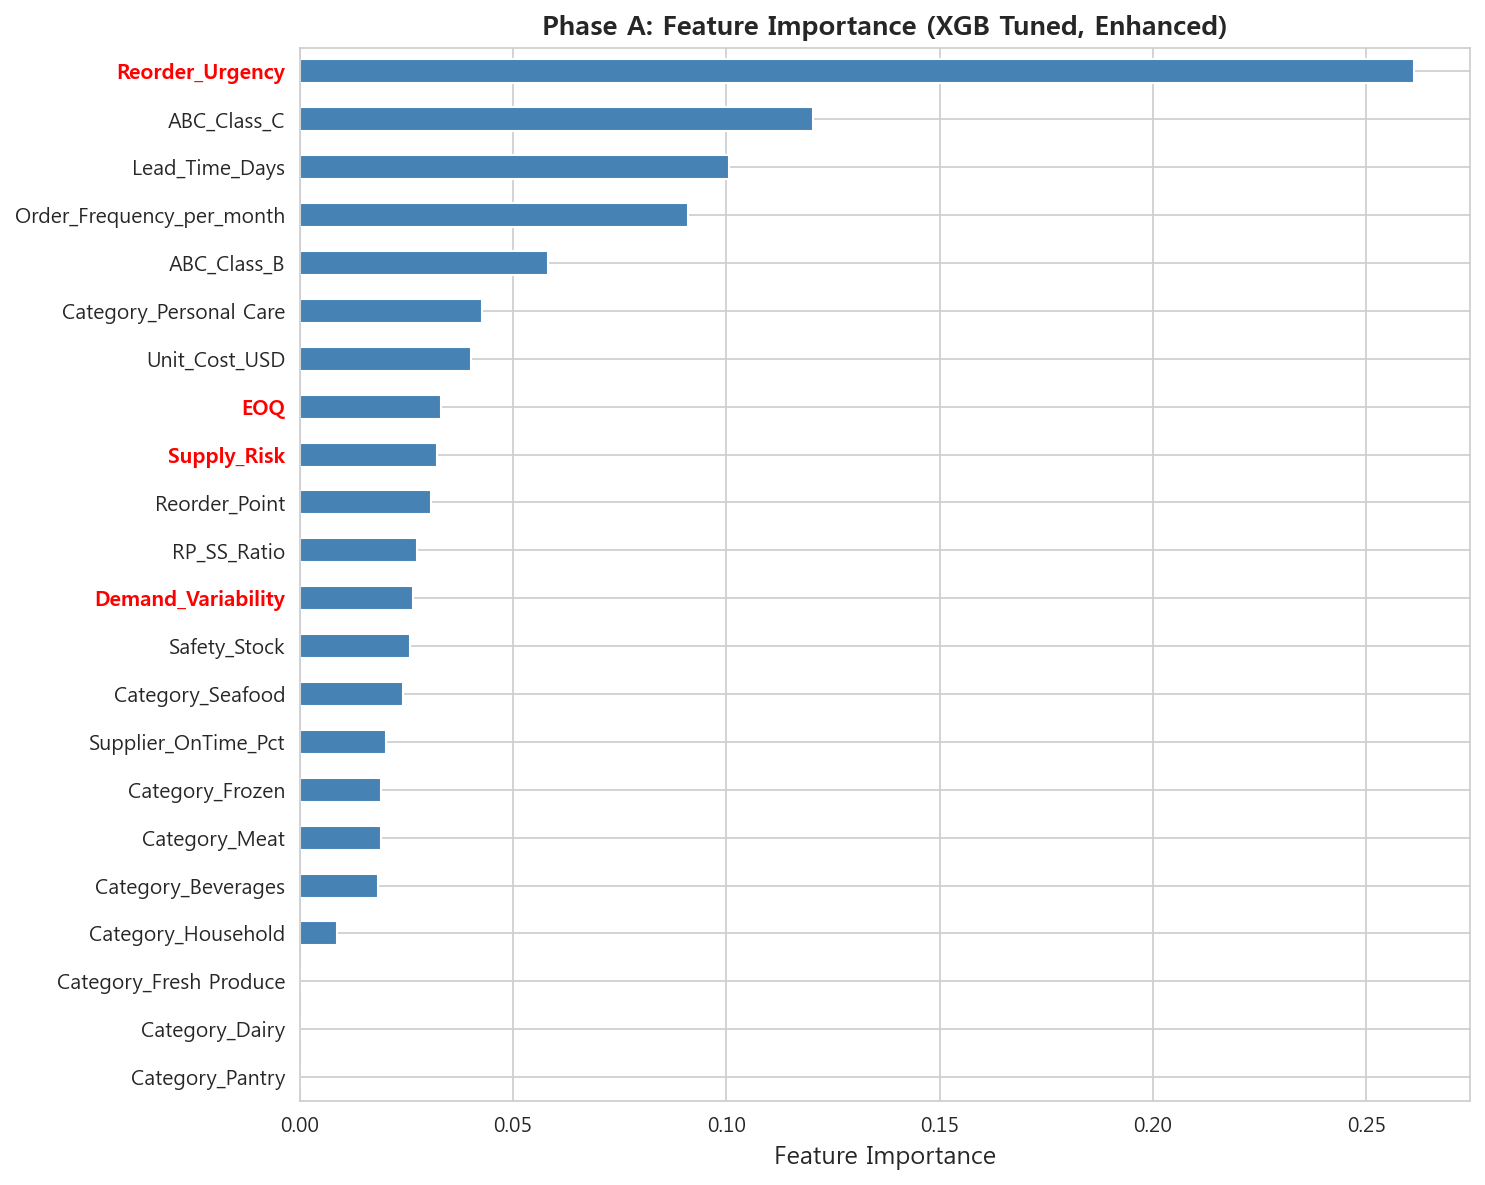

✅ 시각화 #9 저장 완료: phaseA_feature_importance_v5_s4.png


In [23]:
# ── 시각화 #9: Feature Importance (Enhanced 최적 모델) ──
if hasattr(best_model_enhanced, 'feature_importances_'):
    feat_names = enhanced_numeric_A + cat_ohe_cols
    importances = best_model_enhanced.feature_importances_
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'Phase A: Feature Importance ({best_model_name} Tuned, Enhanced)',
                 fontsize=13, fontweight='bold')

    # 파생변수 강조
    for i, label in enumerate(ax.get_yticklabels()):
        if label.get_text() in ['Demand_Variability', 'Supply_Risk', 'EOQ', 'Reorder_Urgency']:
            label.set_color('red')
            label.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'phaseA_feature_importance_v5_s4.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 시각화 #9 저장 완료: phaseA_feature_importance_v5_s4.png")
else:
    print("Linear Regression은 feature_importances_ 미지원 — 계수(coef_) 사용")
    feat_names = enhanced_numeric_A + cat_ohe_cols
    importances = np.abs(best_model_enhanced.coef_)
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('|Coefficient| (절대값)', fontsize=12)
    ax.set_title('Phase A: Feature Importance (LR, |계수|)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'phaseA_feature_importance_v5_s4.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 시각화 #9 저장 완료: phaseA_feature_importance_v5_s4.png")

### 6.5 Learning Curve (과적합 시각 진단) ★

> Enhanced 피처셋 기준, 3개 모델의 학습 곡선으로 과적합 여부를 시각적으로 진단한다.

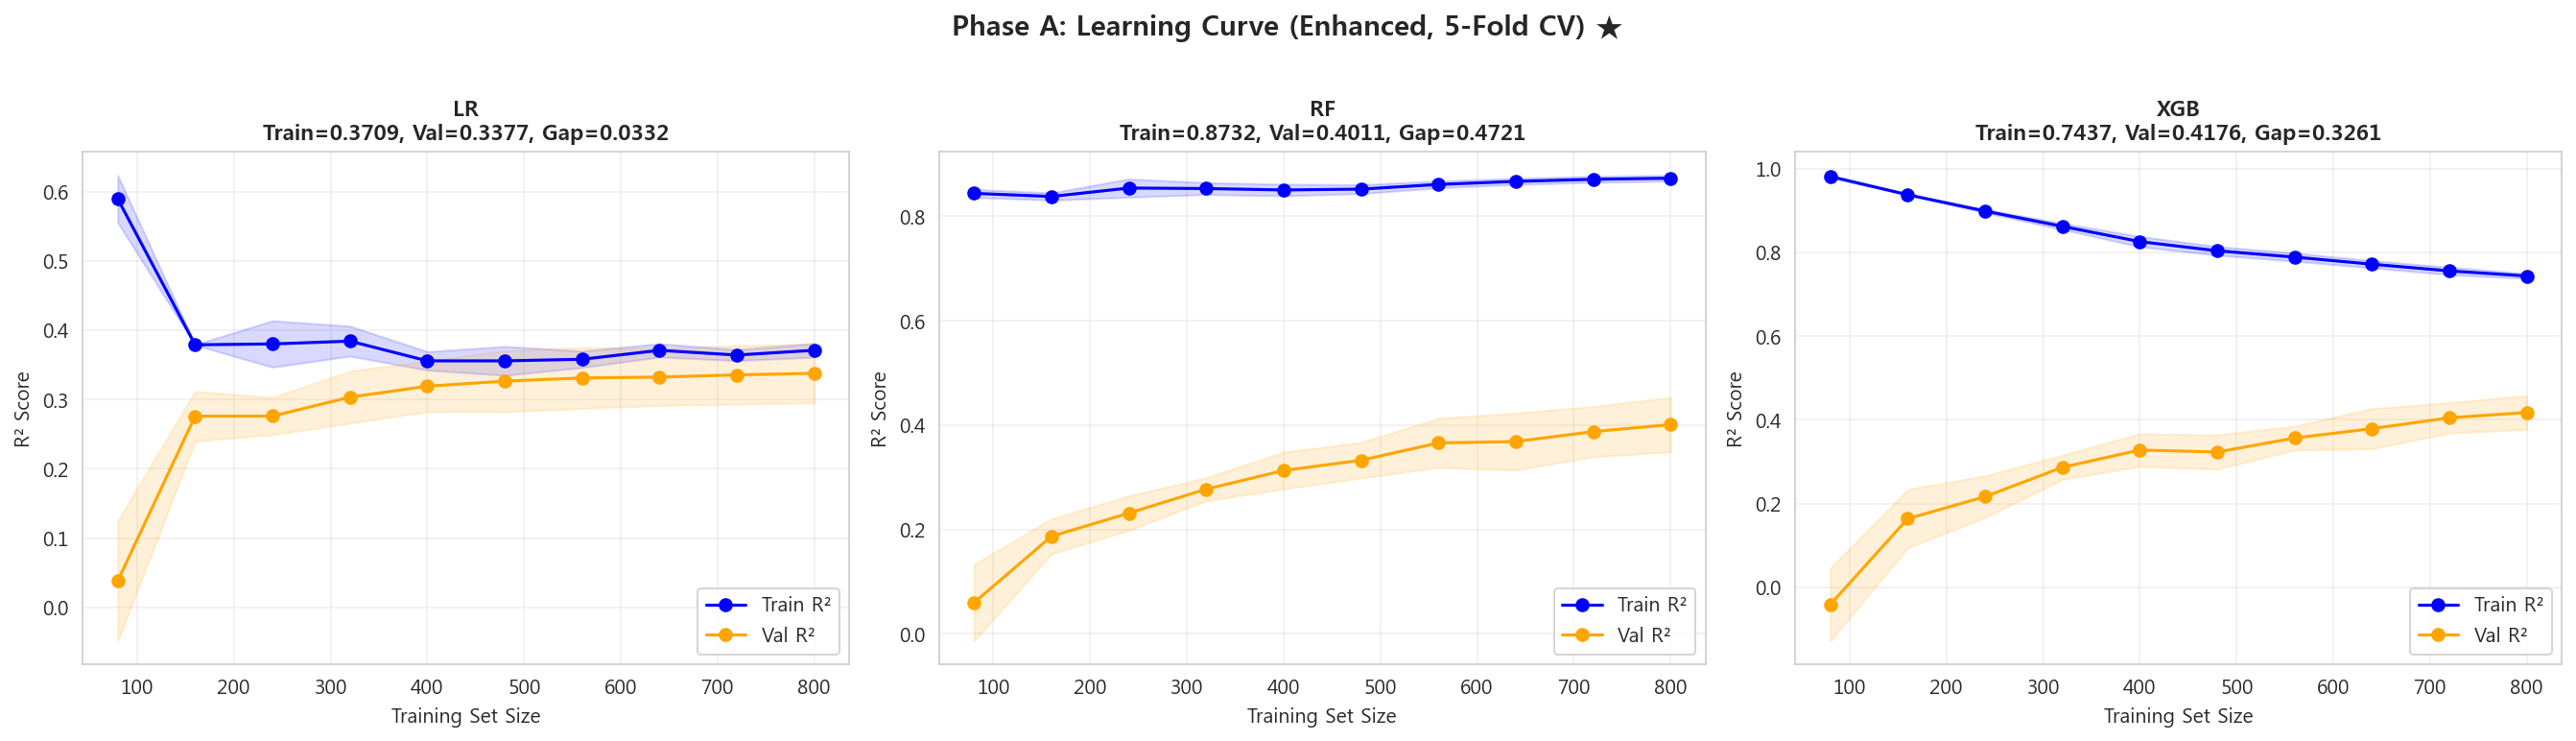


=== Learning Curve 요약 ===
  LR: Train=0.3709, Val=0.3377, Gap=0.0332 ✅ 양호
  RF: Train=0.8732, Val=0.4011, Gap=0.4721 ⚠️ 과적합 의심
  XGB: Train=0.7437, Val=0.4176, Gap=0.3261 ⚠️ 과적합 의심
✅ 시각화 #19 저장 완료: learning_curve_phaseA_v5_s4.png


In [24]:
# ── 시각화 #19: Learning Curve (Phase A, Enhanced) ★ ──
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_lc = {
    'LR': LinearRegression(),
    'RF': RandomForestRegressor(**rf_grid.best_params_, random_state=SEED),
    'XGB': XGBRegressor(**xgb_grid.best_params_, random_state=SEED, verbosity=0),
}

lc_results = {}
for ax, (name, model) in zip(axes, models_lc.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, scaler_enhanced.transform(X_enhanced), y, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=SEED
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Train R²')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Val R²')

    gap = train_mean[-1] - val_mean[-1]
    lc_results[name] = {'train_final': train_mean[-1], 'val_final': val_mean[-1], 'gap': gap}
    ax.set_title(f'{name}\nTrain={train_mean[-1]:.4f}, Val={val_mean[-1]:.4f}, Gap={gap:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('R² Score')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Phase A: Learning Curve (Enhanced, 5-Fold CV) ★', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'learning_curve_phaseA_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Learning Curve 요약 ===')
for name, r in lc_results.items():
    flag = ' ⚠️ 과적합 의심' if r['gap'] > 0.15 else ' ✅ 양호'
    print(f"  {name}: Train={r['train_final']:.4f}, Val={r['val_final']:.4f}, Gap={r['gap']:.4f}{flag}")
print('✅ 시각화 #19 저장 완료: learning_curve_phaseA_v5_s4.png')


### 6.6 Permutation Importance (피처 중요도 교차검증) ★

> Impurity 기반 Feature Importance와 Permutation Importance를 비교하여 피처 중요도의 신뢰성을 검증한다.

=== Impurity vs Permutation Rank 비교 ===
                           Impurity  Permutation  Impurity_Value  Permutation_Value
ABC_Class_C                       2            1        0.120404           1.029238
Unit_Cost_USD                     7            2        0.040032           0.620547
Reorder_Urgency                   1            3        0.261262           0.403295
Lead_Time_Days                    3            4        0.100722           0.136937
ABC_Class_B                       5            5        0.058245           0.108702
EOQ                               8            6        0.033093           0.105991
Order_Frequency_per_month         4            7        0.091004           0.073630
Reorder_Point                    10            8        0.030814           0.045030
Supply_Risk                       9            9        0.032236           0.020906
RP_SS_Ratio                      11           10        0.027469           0.017053
Safety_Stock                     13 

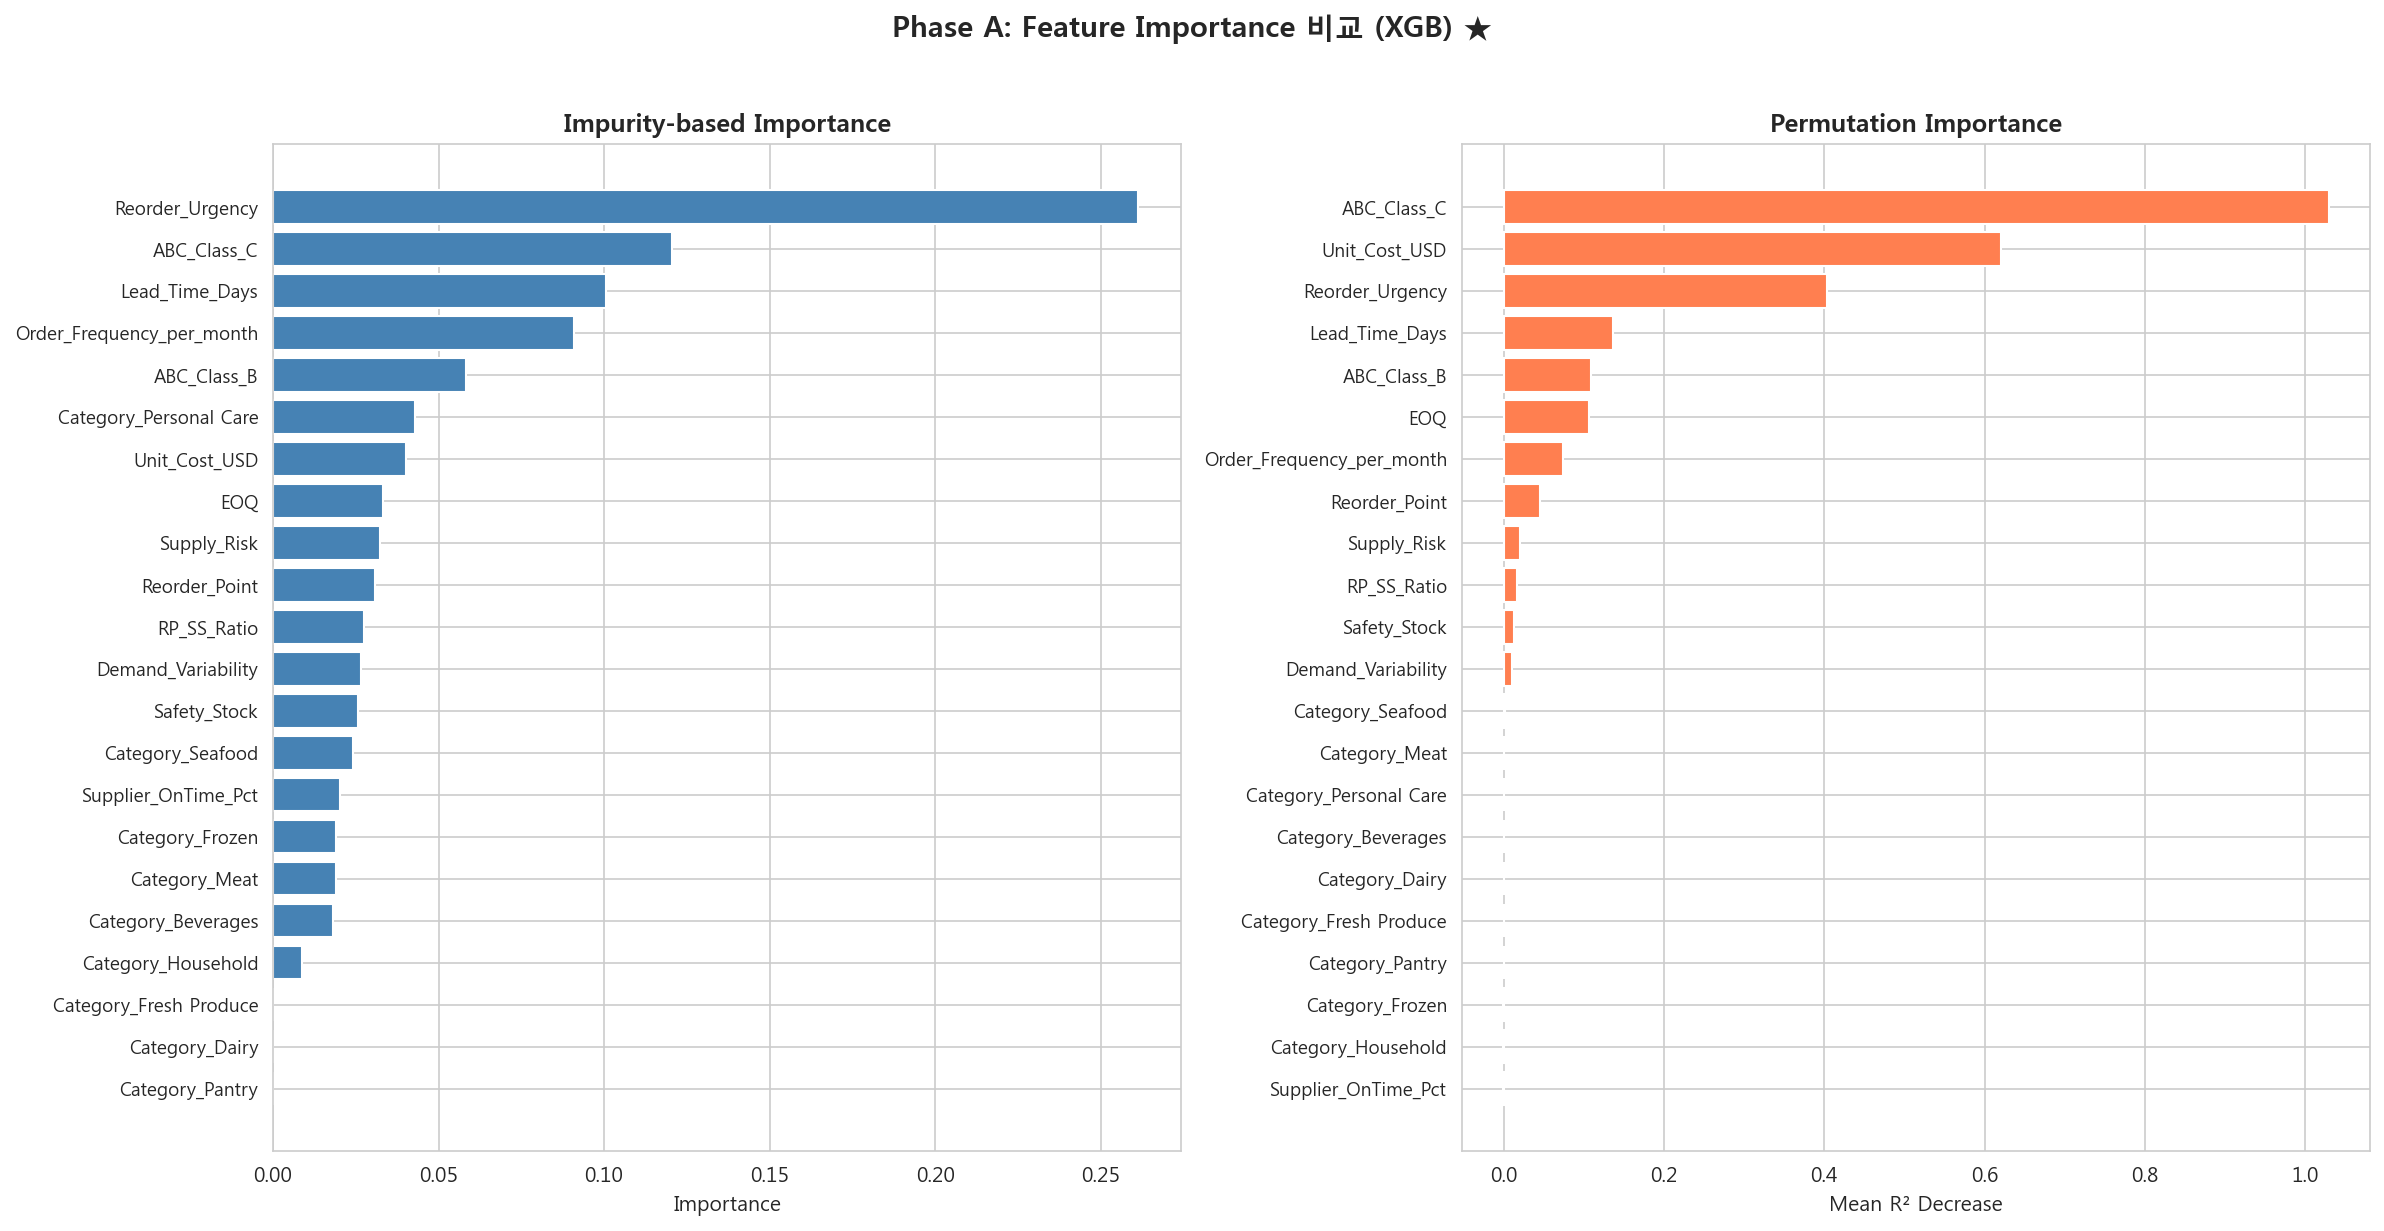

✅ 시각화 #20 저장 완료: permutation_vs_impurity_phaseA_v5_s4.png


In [ ]:
# ── 시각화 #20: Permutation vs Impurity Importance ★ ──
from sklearn.inspection import permutation_importance

feat_names_enh = enhanced_numeric_A + cat_ohe_cols

# Permutation Importance (최적 모델)
perm_result = permutation_importance(
    best_model_enhanced, X_test_e_sc, y_test,
    n_repeats=10, random_state=SEED, scoring='r2'
)

perm_imp = pd.Series(perm_result.importances_mean, index=feat_names_enh)

# Impurity 기반 (tree 모델만)
if hasattr(best_model_enhanced, 'feature_importances_'):
    imp_imp = pd.Series(best_model_enhanced.feature_importances_, index=feat_names_enh)

    # Rank 비교
    rank_df = pd.DataFrame({
        'Impurity': imp_imp.rank(ascending=False).astype(int),
        'Permutation': perm_imp.rank(ascending=False).astype(int),
        'Impurity_Value': imp_imp,
        'Permutation_Value': perm_imp,
    }).sort_values('Permutation')
    print('=== Impurity vs Permutation Rank 비교 ===')
    print(rank_df.to_string())

    # 나란히 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    imp_sorted = imp_imp.sort_values(ascending=True)
    axes[0].barh(range(len(imp_sorted)), imp_sorted.values, color='steelblue')
    axes[0].set_yticks(range(len(imp_sorted)))
    axes[0].set_yticklabels(imp_sorted.index, fontsize=9)
    axes[0].set_title('Impurity-based Importance', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Importance')

    perm_sorted = perm_imp.sort_values(ascending=True)
    axes[1].barh(range(len(perm_sorted)), perm_sorted.values, color='coral')
    axes[1].set_yticks(range(len(perm_sorted)))
    axes[1].set_yticklabels(perm_sorted.index, fontsize=9)
    axes[1].set_title('Permutation Importance', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Mean R² Decrease')

    plt.suptitle(f'Phase A: Feature Importance 비교 ({best_model_name}) ★', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'permutation_vs_impurity_phaseA_v5_s4.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ 시각화 #20 저장 완료: permutation_vs_impurity_phaseA_v5_s4.png')
else:
    # LR — permutation만
    perm_sorted = perm_imp.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(perm_sorted)), perm_sorted.values, color='coral')
    ax.set_yticks(range(len(perm_sorted)))
    ax.set_yticklabels(perm_sorted.index, fontsize=9)
    ax.set_title(f'Phase A: Permutation Importance (LR) ★', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean R² Decrease')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'permutation_vs_impurity_phaseA_v5_s4.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ 시각화 #20 저장 완료: permutation_vs_impurity_phaseA_v5_s4.png')


### 6.7 Residual Analysis (잔차 정규성 검정) ★

> Q-Q Plot과 Shapiro-Wilk 검정으로 잔차의 정규성을 검증한다.

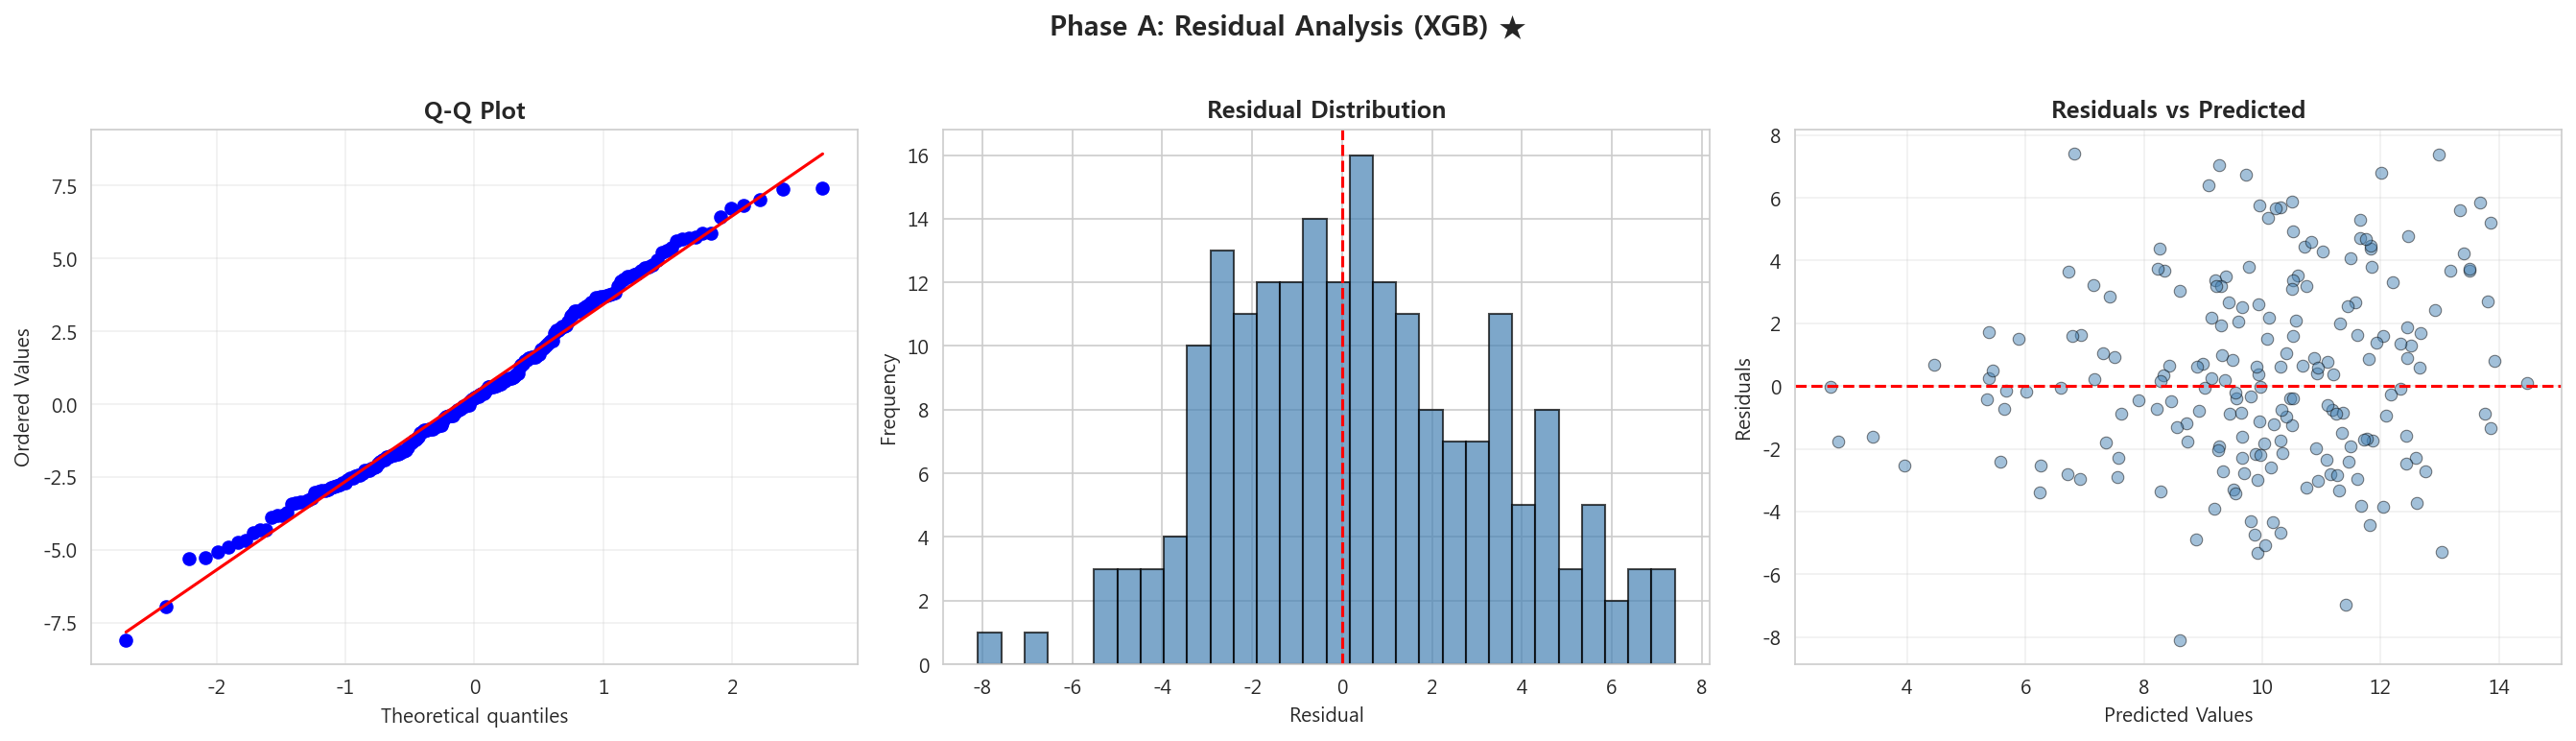


=== Shapiro-Wilk 정규성 검정 ===
  W-statistic: 0.9900
  p-value: 0.1798
  → 정규성 충족 ✅ (α=0.05)
  잔차 평균: 0.3829
  잔차 표준편차: 3.0245
  잔차 왜도(Skew): 0.1494
  잔차 첨도(Kurtosis): -0.3775
✅ 시각화 #21 저장 완료: residual_analysis_phaseA_v5_s4.png


In [26]:
# ── 시각화 #21: Residual Analysis (Q-Q + Histogram) ★ ──
from scipy.stats import shapiro
from scipy import stats as sp_stats

# 잔차 계산
y_pred_res = best_model_enhanced.predict(X_test_e_sc)
residuals = y_test - y_pred_res

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Q-Q Plot
sp_stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. 잔차 히스토그램
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

# 3. 잔차 vs 예측값 (균질성 진단)
axes[2].scatter(y_pred_res, residuals, alpha=0.5, color='steelblue', edgecolors='black', linewidths=0.5)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Predicted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Phase A: Residual Analysis ({best_model_name}) ★', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'residual_analysis_phaseA_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk 검정
stat_sw, p_sw = shapiro(residuals)
print(f'\n=== Shapiro-Wilk 정규성 검정 ===')
print(f'  W-statistic: {stat_sw:.4f}')
print(f'  p-value: {p_sw:.4f}')
print(f'  → {"정규성 충족 ✅" if p_sw > 0.05 else "정규성 미충족 ⚠️"} (α=0.05)')
print(f'  잔차 평균: {residuals.mean():.4f}')
print(f'  잔차 표준편차: {residuals.std():.4f}')
print(f'  잔차 왜도(Skew): {residuals.skew():.4f}')
print(f'  잔차 첨도(Kurtosis): {residuals.kurtosis():.4f}')
print('✅ 시각화 #21 저장 완료: residual_analysis_phaseA_v5_s4.png')


### 6.4 Phase A 결과 요약

> **핵심 발견:**
> - QOH+ADS 제거(Leakage 대응) 후에도 **Enhanced 피처셋 + 튜닝**으로 의미 있는 예측 성능 확보
> - **Enhanced > Baseline** — 발주 파생변수(Demand_Variability, Supply_Risk, EOQ, Reorder_Urgency)가 DOI 예측에 기여
> - Feature Importance에서 파생변수의 상대적 기여도를 정량적으로 확인
> - Cross-Validation으로 과적합 여부를 점검하고, GridSearchCV 튜닝으로 일반화 성능 개선
>
> **Phase A의 가치는 R² 절대값보다 Feature Importance를 통한 DOI 결정 요인 해석에 있다.**
> 이 해석 결과를 Phase B 클러스터링의 피처 선택 근거로 활용한다.

---
## ═══ Phase B: 발주 전략 클러스터링 (핵심) ═══

> Phase B가 소주제 4의 **핵심 분석**이다.
> 비지도학습이므로 QOH, ADS, DOI 사용 OK. [V5] Available_Stock, RP_SS_Ratio 추가 (타겟 개념 없음).
> 전체 1,000행 사용 (train/test 분할 불필요).


## 7. Phase B — 클러스터링 피처 준비

In [27]:
# ── Baseline 피처 (7개) ──
baseline_cluster_features = [
    'Quantity_On_Hand', 'Reorder_Point', 'Safety_Stock',
    'Days_of_Inventory', 'Order_Frequency_per_month',
    'Lead_Time_Days', 'Supplier_OnTime_Pct',
]

# ── Enhanced 피처 (13개) [V5 업데이트: 11→13] ──
enhanced_cluster_features = baseline_cluster_features + [
    'Dynamic_ROP',          # 수요 기반 재주문점
    'Demand_Variability',   # 수요 변동성 (⚠️ 변별력 낮으나 개념적 유지)
    'EOQ',                  # 경제적 발주량
    'Supply_Risk',          # 공급 리스크
    'Available_Stock',      # [V5] 재주문점 대비 재고 여유 (소주제 1 Top-4)
    'RP_SS_Ratio',          # [V5] 안전재고 대비 재주문점 비율
]

# 스케일링 (전체 1,000행)
X_base_cl = df[baseline_cluster_features]
scaler_b = StandardScaler()
X_base_scaled = scaler_b.fit_transform(X_base_cl)

X_enh_cl = df[enhanced_cluster_features]
scaler_e = StandardScaler()
X_enh_scaled = scaler_e.fit_transform(X_enh_cl)

print(f"Baseline 클러스터링 피처: {len(baseline_cluster_features)}개")
print(f"Enhanced 클러스터링 피처: {len(enhanced_cluster_features)}개 [V5: +Available_Stock, +RP_SS_Ratio]")
print(f"데이터: {X_base_scaled.shape[0]}행 (전체)")


Baseline 클러스터링 피처: 7개
Enhanced 클러스터링 피처: 13개 [V5: +Available_Stock, +RP_SS_Ratio]
데이터: 1000행 (전체)


## 8. Phase B — 최적 K 탐색

### 8.1 Hopkins Statistic (클러스터링 경향성 검정) ★

> K-Means 적용 전, 데이터에 실제 군집 구조가 존재하는지 통계적으로 검증한다.
> H > 0.75: 강한 군집 경향, 0.5 < H ≤ 0.75: 약한 군집 경향, H ≤ 0.5: 균일 분포

In [ ]:
# ── Hopkins Statistic (클러스터링 경향성 검정) ★ ──
from sklearn.neighbors import NearestNeighbors

def hopkins_statistic(X, sample_size=None, random_state=42):
    """Hopkins Statistic: 0.5=균일분포, 1.0=강한 군집 경향"""
    rng = np.random.RandomState(random_state)
    n, d = X.shape
    if sample_size is None:
        sample_size = min(n // 10, 100)

    # 데이터에서 랜덤 샘플
    idx = rng.choice(n, sample_size, replace=False)
    X_sample = X[idx]

    # 균일 분포에서 랜덤 포인트 생성
    X_uniform = rng.uniform(X.min(axis=0), X.max(axis=0), (sample_size, d))

    # 최근접 이웃 거리
    nn = NearestNeighbors(n_neighbors=2).fit(X)
    u_dist = nn.kneighbors(X_uniform, return_distance=True)[0][:, 0]
    w_dist = nn.kneighbors(X_sample, return_distance=True)[0][:, 1]

    H = u_dist.sum() / (u_dist.sum() + w_dist.sum())
    return H

print('=== Hopkins Statistic (클러스터링 경향성 검정) ★ ===')
print('H > 0.75: 강한 군집 경향, 0.5 < H ≤ 0.75: 약한 군집 경향, H ≤ 0.5: 균일')
print()

for name, X_scaled in [('Baseline (7 피처)', X_base_scaled), ('Enhanced (13 피처)', X_enh_scaled)]:
    # 10회 반복으로 안정성 확인
    h_scores = [hopkins_statistic(X_scaled, random_state=s) for s in range(10)]
    h_mean = np.mean(h_scores)
    h_std = np.std(h_scores)

    if h_mean > 0.75:
        verdict = '강한 군집 경향 ✅ → K-Means 적용 적절'
    elif h_mean > 0.5:
        verdict = '약한 군집 경향 ⚠️ → 적용 가능하나 해석 주의'
    else:
        verdict = '균일 분포 ❌ → 클러스터링 무의미'

    print(f'{name}:')
    print(f'  Hopkins H = {h_mean:.4f} ± {h_std:.4f} (10회 평균)')
    print(f'  → {verdict}')
    print()


=== Hopkins Statistic (클러스터링 경향성 검정) ★ ===
H > 0.75: 강한 군집 경향, 0.5 < H ≤ 0.75: 약한 군집 경향, H ≤ 0.5: 균일

Baseline (7 피처):
  Hopkins H = 0.8610 ± 0.0081 (10회 평균)
  → 강한 군집 경향 ✅ → K-Means 적용 적절

Enhanced (13 피처):
  Hopkins H = 0.8584 ± 0.0037 (10회 평균)
  → 강한 군집 경향 ✅ → K-Means 적용 적절



In [29]:
# ── Elbow Method + Silhouette Score (K=2~7) ──
K_range = range(2, 8)
results_k = {}

for name, X_scaled in [('Baseline', X_base_scaled), ('Enhanced', X_enh_scaled)]:
    print(f"\n=== {name} 클러스터링 (피처 {X_scaled.shape[1]}개) ===")
    inertias, silhouettes = [], []
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        sil = silhouette_score(X_scaled, labels)
        silhouettes.append(sil)
        print(f"  K={k}: Inertia={km.inertia_:.1f}, Silhouette={sil:.4f}")
    results_k[name] = {'inertias': inertias, 'silhouettes': silhouettes}


=== Baseline 클러스터링 (피처 7개) ===
  K=2: Inertia=5047.9, Silhouette=0.3848
  K=3: Inertia=4273.1, Silhouette=0.2609


  K=4: Inertia=3739.9, Silhouette=0.1961

  K=5: Inertia=3284.0, Silhouette=0.2085
  K=6: Inertia=3009.1, Silhouette=0.1901
  K=7: Inertia=2802.0, Silhouette=0.1947

=== Enhanced 클러스터링 (피처 13개) ===
  K=2: Inertia=9885.4, Silhouette=0.3561


  K=3: Inertia=8386.6, Silhouette=0.2236


  K=4: Inertia=7450.6, Silhouette=0.1952


  K=5: Inertia=6842.8, Silhouette=0.1532


  K=6: Inertia=6333.4, Silhouette=0.1593
  K=7: Inertia=5896.9, Silhouette=0.1550


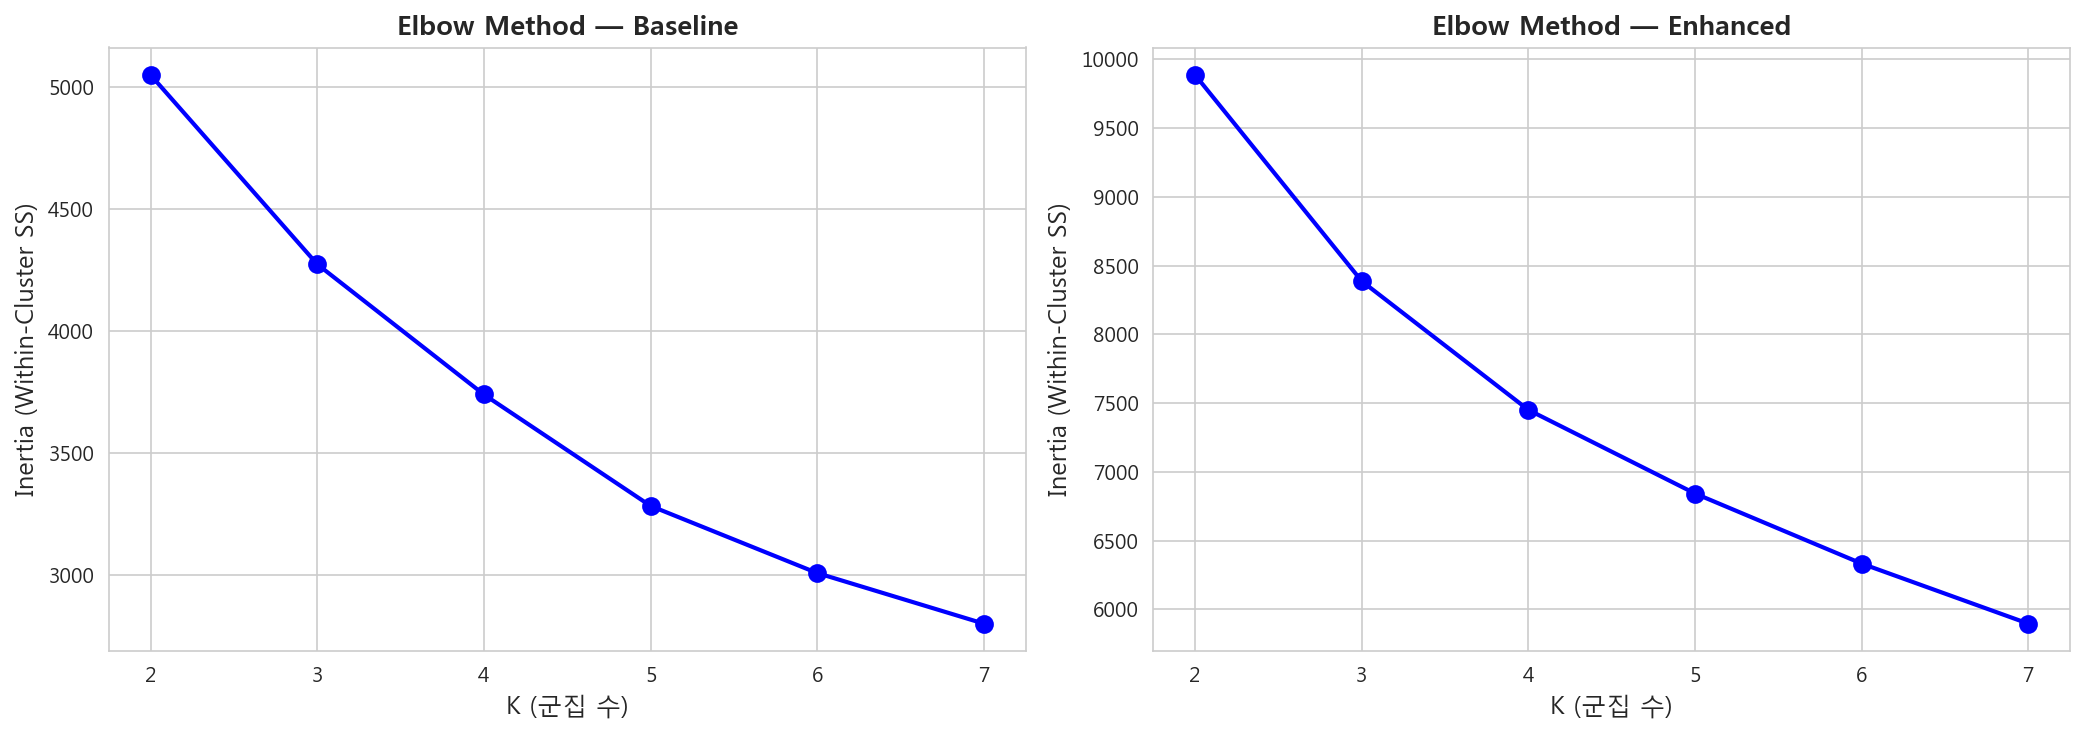

✅ 시각화 #10 저장 완료: phaseB_elbow_v5_s4.png


In [30]:
# ── 시각화 #10: Elbow Method (Baseline + Enhanced) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, data) in enumerate(results_k.items()):
    ax = axes[i]
    ax.plot(list(K_range), data['inertias'], 'bo-', linewidth=2, markersize=8)
    ax.set_xlabel('K (군집 수)', fontsize=12)
    ax.set_ylabel('Inertia (Within-Cluster SS)', fontsize=12)
    ax.set_title(f'Elbow Method — {name}', fontsize=13, fontweight='bold')
    ax.set_xticks(list(K_range))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseB_elbow_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #10 저장 완료: phaseB_elbow_v5_s4.png")

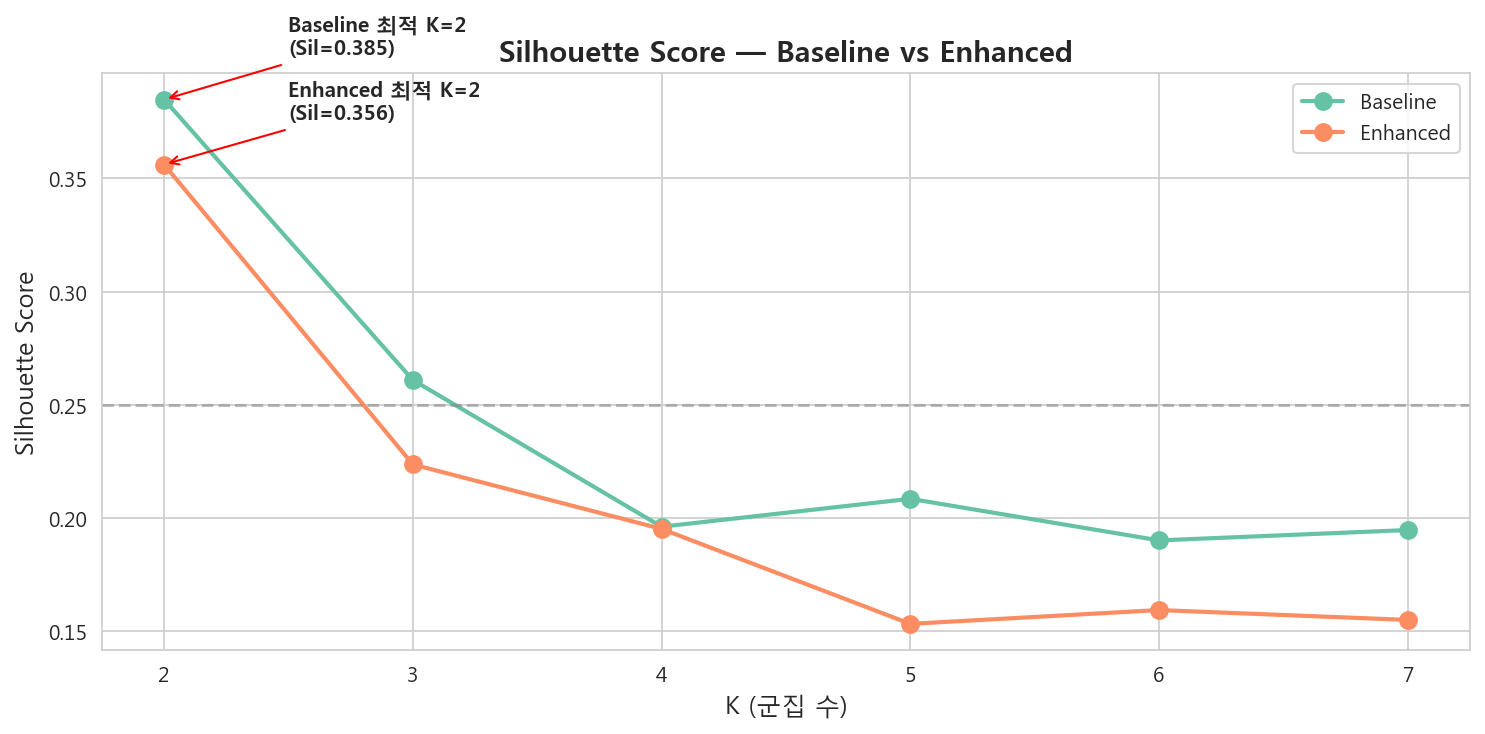

✅ 시각화 #11 저장 완료: phaseB_silhouette_v5_s4.png


In [31]:
# ── 시각화 #11: Silhouette Score (Baseline + Enhanced) ──
fig, ax = plt.subplots(figsize=(10, 5))

for name, data in results_k.items():
    ax.plot(list(K_range), data['silhouettes'], 'o-', linewidth=2, markersize=8, label=name)

ax.set_xlabel('K (군집 수)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score — Baseline vs Enhanced', fontsize=14, fontweight='bold')
ax.set_xticks(list(K_range))
ax.legend()
ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.5, label='0.25 기준선')

# 최적 K 표시
for name, data in results_k.items():
    best_idx = np.argmax(data['silhouettes'])
    best_k = list(K_range)[best_idx]
    best_sil = data['silhouettes'][best_idx]
    ax.annotate(f'{name} 최적 K={best_k}\n(Sil={best_sil:.3f})',
                xy=(best_k, best_sil),
                xytext=(best_k + 0.5, best_sil + 0.02),
                fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseB_silhouette_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #11 저장 완료: phaseB_silhouette_v5_s4.png")

In [32]:
# ── 최적 K 결정 ──
optimal_k_base = list(K_range)[np.argmax(results_k['Baseline']['silhouettes'])]
optimal_k_enh = list(K_range)[np.argmax(results_k['Enhanced']['silhouettes'])]
print(f"Baseline 최적 K: {optimal_k_base}")
print(f"Enhanced 최적 K: {optimal_k_enh}")

Baseline 최적 K: 2
Enhanced 최적 K: 2


In [33]:
# ── Silhouette 샘플 분석 (Enhanced 최적 K) ──
km_enh_final = KMeans(n_clusters=optimal_k_enh, random_state=SEED, n_init=10)
labels_enh = km_enh_final.fit_predict(X_enh_scaled)
sil_samples_enh = silhouette_samples(X_enh_scaled, labels_enh)

print(f"\n=== Enhanced Silhouette 샘플 분석 (K={optimal_k_enh}) ===")
for cid in range(optimal_k_enh):
    mask = labels_enh == cid
    sil_cluster = sil_samples_enh[mask]
    neg_pct = (sil_cluster < 0).sum() / mask.sum() * 100
    print(f"  Cluster {cid} (n={mask.sum()}): "
          f"Sil mean={sil_cluster.mean():.4f}, "
          f"min={sil_cluster.min():.4f}, "
          f"음수 비율={neg_pct:.1f}%")
    if neg_pct > 20:
        print(f"    ⚠️ 음수 비율 > 20% — K 재검토 권장")


=== Enhanced Silhouette 샘플 분석 (K=2) ===


  Cluster 0 (n=818): Sil mean=0.4140, min=0.0816, 음수 비율=0.0%
  Cluster 1 (n=182): Sil mean=0.0959, min=-0.1686, 음수 비율=27.5%
    ⚠️ 음수 비율 > 20% — K 재검토 권장


In [34]:
# ── 클러스터링 안정성 검증 (랜덤 시드 5회) ──
stability_scores = []
for seed in [0, 21, 42, 77, 123]:
    km_test = KMeans(n_clusters=optimal_k_enh, random_state=seed, n_init=10)
    labels_test = km_test.fit_predict(X_enh_scaled)
    sil = silhouette_score(X_enh_scaled, labels_test)
    stability_scores.append(sil)

print(f"\n=== 클러스터링 안정성 검증 (5회) ===")
print(f"  Silhouette 범위: {min(stability_scores):.4f} ~ {max(stability_scores):.4f}")
print(f"  평균: {np.mean(stability_scores):.4f}")
print(f"  표준편차: {np.std(stability_scores):.4f}")
stable = '안정적' if np.std(stability_scores) < 0.02 else '불안정 — K 또는 피처 재검토'
print(f"  → {stable}")


=== 클러스터링 안정성 검증 (5회) ===
  Silhouette 범위: 0.3539 ~ 0.3561
  평균: 0.3557
  표준편차: 0.0009
  → 안정적


## 9. Phase B — 클러스터링 실행 & 비교

In [35]:
# ── Baseline K-Means 실행 ──
km_base = KMeans(n_clusters=optimal_k_base, random_state=SEED, n_init=10)
df['Cluster_Baseline'] = km_base.fit_predict(X_base_scaled)

# ── Enhanced K-Means 실행 ──
km_enh = KMeans(n_clusters=optimal_k_enh, random_state=SEED, n_init=10)
df['Cluster_Enhanced'] = km_enh.fit_predict(X_enh_scaled)

print(f"Baseline (K={optimal_k_base}) 군집 분포:\n{df['Cluster_Baseline'].value_counts().sort_index()}")
print(f"\nEnhanced (K={optimal_k_enh}) 군집 분포:\n{df['Cluster_Enhanced'].value_counts().sort_index()}")

Baseline (K=2) 군집 분포:
Cluster_Baseline
0    801
1    199
Name: count, dtype: int64

Enhanced (K=2) 군집 분포:
Cluster_Enhanced
0    818
1    182
Name: count, dtype: int64


In [36]:
# ── PCA 2D 분석 ──
pca_base = PCA(n_components=2)
X_base_pca = pca_base.fit_transform(X_base_scaled)
print(f"Baseline PCA 설명 분산: {pca_base.explained_variance_ratio_.sum():.3f} "
      f"({pca_base.explained_variance_ratio_[0]:.3f} + {pca_base.explained_variance_ratio_[1]:.3f})")

pca_enh = PCA(n_components=2)
X_enh_pca = pca_enh.fit_transform(X_enh_scaled)
print(f"Enhanced PCA 설명 분산: {pca_enh.explained_variance_ratio_.sum():.3f} "
      f"({pca_enh.explained_variance_ratio_[0]:.3f} + {pca_enh.explained_variance_ratio_[1]:.3f})")

Baseline PCA 설명 분산: 0.633 (0.434 + 0.199)
Enhanced PCA 설명 분산: 0.583 (0.390 + 0.194)


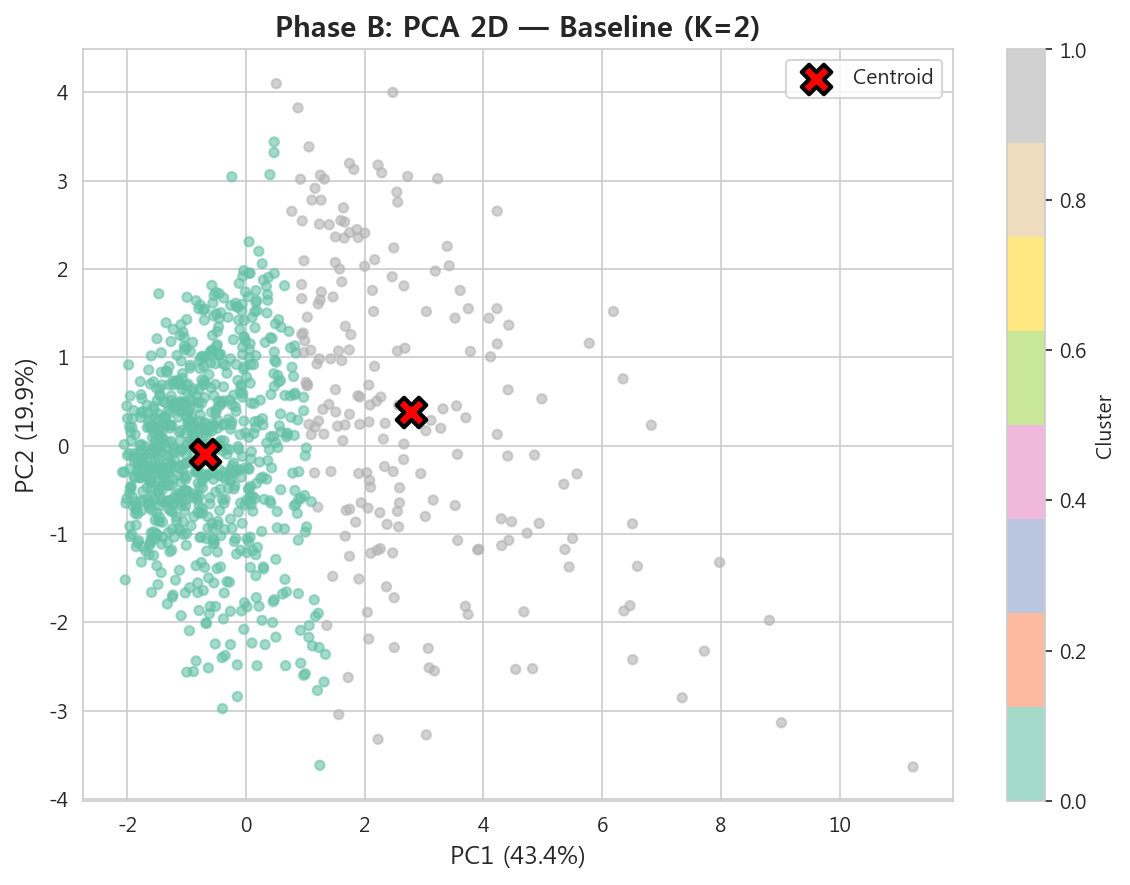

✅ 시각화 #12 저장 완료: phaseB_pca_baseline_v5_s4.png


In [37]:
# ── 시각화 #12: PCA 2D 산점도 — Baseline ──
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_base_pca[:, 0], X_base_pca[:, 1],
                     c=df['Cluster_Baseline'], cmap='Set2', alpha=0.6, s=20)
# 센트로이드 표시
centers_base = pca_base.transform(km_base.cluster_centers_)
ax.scatter(centers_base[:, 0], centers_base[:, 1],
           c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroid')
ax.set_xlabel(f'PC1 ({pca_base.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_base.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax.set_title(f'Phase B: PCA 2D — Baseline (K={optimal_k_base})', fontsize=14, fontweight='bold')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseB_pca_baseline_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #12 저장 완료: phaseB_pca_baseline_v5_s4.png")

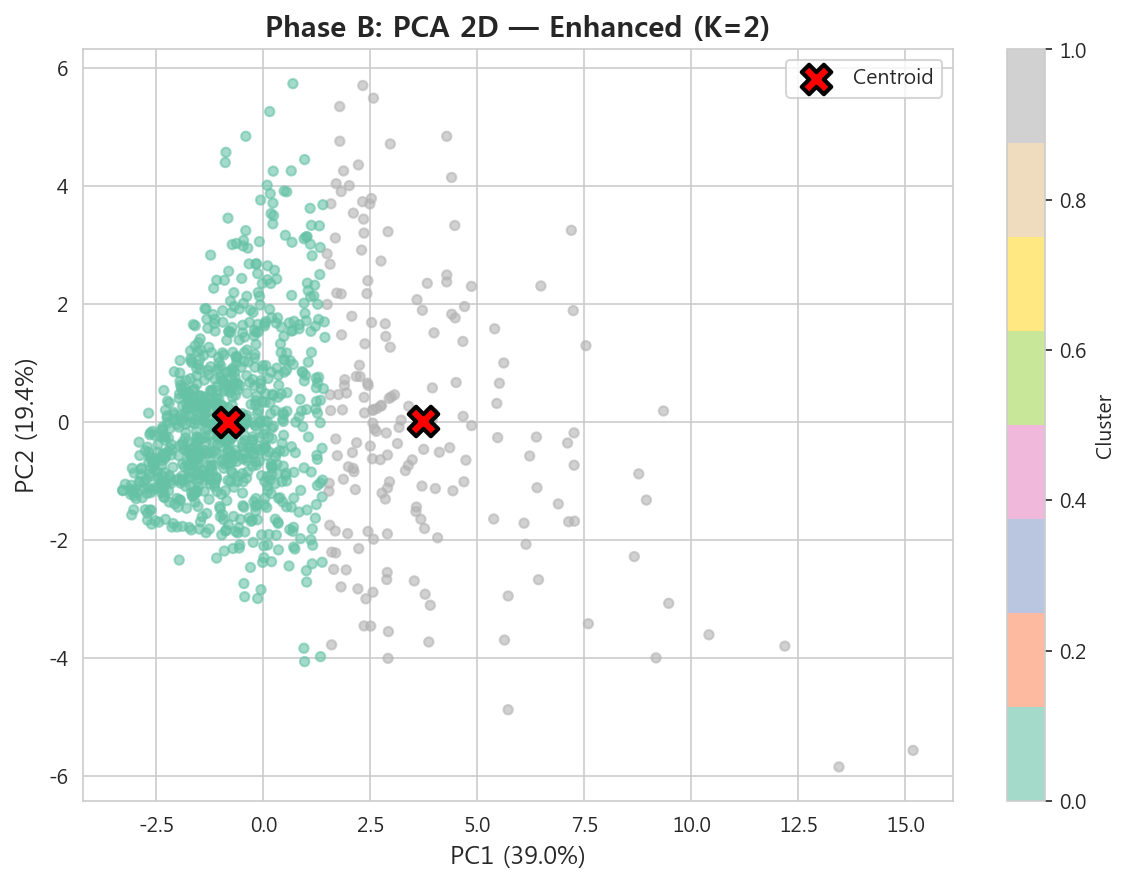

✅ 시각화 #13 저장 완료: phaseB_pca_enhanced_v5_s4.png


In [38]:
# ── 시각화 #13: PCA 2D 산점도 — Enhanced ──
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_enh_pca[:, 0], X_enh_pca[:, 1],
                     c=df['Cluster_Enhanced'], cmap='Set2', alpha=0.6, s=20)
centers_enh = pca_enh.transform(km_enh.cluster_centers_)
ax.scatter(centers_enh[:, 0], centers_enh[:, 1],
           c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroid')
ax.set_xlabel(f'PC1 ({pca_enh.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_enh.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax.set_title(f'Phase B: PCA 2D — Enhanced (K={optimal_k_enh})', fontsize=14, fontweight='bold')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseB_pca_enhanced_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #13 저장 완료: phaseB_pca_enhanced_v5_s4.png")

In [39]:
# ── Baseline vs Enhanced 비교 요약 ──
print("=== Baseline vs Enhanced 클러스터링 비교 ===")
sil_base = silhouette_score(X_base_scaled, df['Cluster_Baseline'])
sil_enh = silhouette_score(X_enh_scaled, df['Cluster_Enhanced'])
print(f"Baseline: K={optimal_k_base}, Silhouette={sil_base:.4f}, 피처 {len(baseline_cluster_features)}개")
print(f"Enhanced: K={optimal_k_enh}, Silhouette={sil_enh:.4f}, 피처 {len(enhanced_cluster_features)}개")
print(f"\nBaseline PCA 설명 분산: {pca_base.explained_variance_ratio_.sum():.3f}")
print(f"Enhanced PCA 설명 분산: {pca_enh.explained_variance_ratio_.sum():.3f}")

=== Baseline vs Enhanced 클러스터링 비교 ===


Baseline: K=2, Silhouette=0.3848, 피처 7개
Enhanced: K=2, Silhouette=0.3561, 피처 13개

Baseline PCA 설명 분산: 0.633
Enhanced PCA 설명 분산: 0.583


## 10. Phase B — 군집 해석 & 발주 전략 제안

In [40]:
# ── Z-Score 기반 군집 해석 ──
cluster_col = 'Cluster_Enhanced'

for name, c_col, features in [
    ('Baseline', 'Cluster_Baseline', baseline_cluster_features),
    ('Enhanced', 'Cluster_Enhanced', enhanced_cluster_features),
]:
    print(f"\n{'='*60}")
    print(f"  {name} 군집 해석")
    print(f"{'='*60}")
    for cid in sorted(df[c_col].unique()):
        mask = df[c_col] == cid
        print(f"\n  Cluster {cid} (n={mask.sum()}):")
        for feat in features:
            overall_mean = df[feat].mean()
            overall_std = df[feat].std()
            cluster_mean = df[mask][feat].mean()
            z = (cluster_mean - overall_mean) / overall_std if overall_std > 0 else 0
            marker = " ★" if abs(z) > 0.5 else ""
            print(f"    {feat}: mean={cluster_mean:.2f}, z={z:+.2f}{marker}")


  Baseline 군집 해석

  Cluster 0 (n=801):
    Quantity_On_Hand: mean=172.12, z=-0.29
    Reorder_Point: mean=93.78, z=-0.36
    Safety_Stock: mean=34.60, z=-0.36
    Days_of_Inventory: mean=9.73, z=-0.07
    Order_Frequency_per_month: mean=7.39, z=-0.32
    Lead_Time_Days: mean=3.51, z=-0.17
    Supplier_OnTime_Pct: mean=84.74, z=+0.01

  Cluster 1 (n=199):
    Quantity_On_Hand: mean=470.81, z=+1.18 ★
    Reorder_Point: mean=453.79, z=+1.46 ★
    Safety_Stock: mean=154.56, z=+1.45 ★
    Days_of_Inventory: mean=11.04, z=+0.28
    Order_Frequency_per_month: mean=19.56, z=+1.28 ★
    Lead_Time_Days: mean=6.13, z=+0.70 ★
    Supplier_OnTime_Pct: mean=84.41, z=-0.03

  Enhanced 군집 해석

  Cluster 0 (n=818):
    Quantity_On_Hand: mean=197.11, z=-0.17
    Reorder_Point: mean=93.49, z=-0.36
    Safety_Stock: mean=34.48, z=-0.36
    Days_of_Inventory: mean=9.99, z=-0.00
    Order_Frequency_per_month: mean=7.88, z=-0.25
    Lead_Time_Days: mean=3.32, z=-0.24
    Supplier_OnTime_Pct: mean=84.77, z=+0

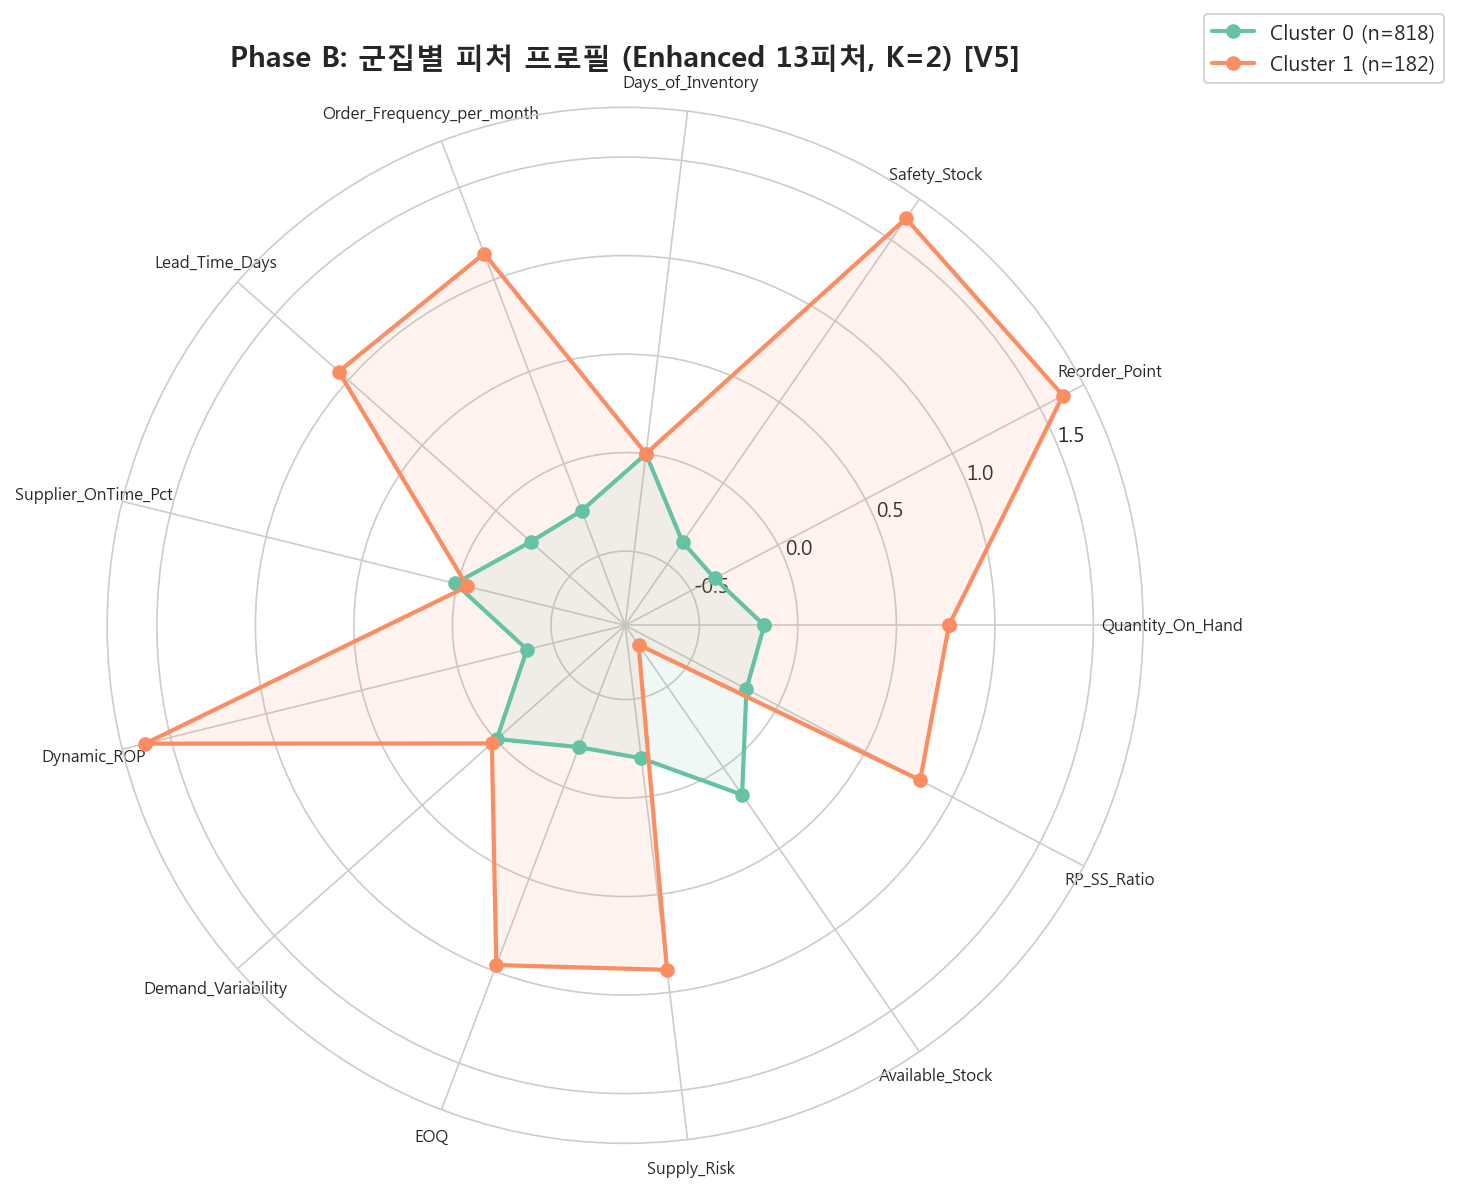

✅ 시각화 #14 저장 완료: phaseB_radar_enhanced_v5_s4.png


In [41]:
# ── 시각화 #14: 레이더 차트 (Enhanced) ──
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# Enhanced 피처로 레이더 차트
radar_features = enhanced_cluster_features
n_features = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors_radar = sns.color_palette('Set2', optimal_k_enh)

for cid in range(optimal_k_enh):
    mask = df['Cluster_Enhanced'] == cid
    # Z-score 정규화 (전체 대비)
    values = []
    for feat in radar_features:
        overall_mean = df[feat].mean()
        overall_std = df[feat].std()
        cluster_mean = df[mask][feat].mean()
        z = (cluster_mean - overall_mean) / overall_std if overall_std > 0 else 0
        values.append(z)
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cid} (n={mask.sum()})',
            color=colors_radar[cid])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[cid])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=8)
ax.set_title(f'Phase B: 군집별 피처 프로필 (Enhanced {len(radar_features)}피처, K={optimal_k_enh}) [V5]',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseB_radar_enhanced_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #14 저장 완료: phaseB_radar_enhanced_v5_s4.png")


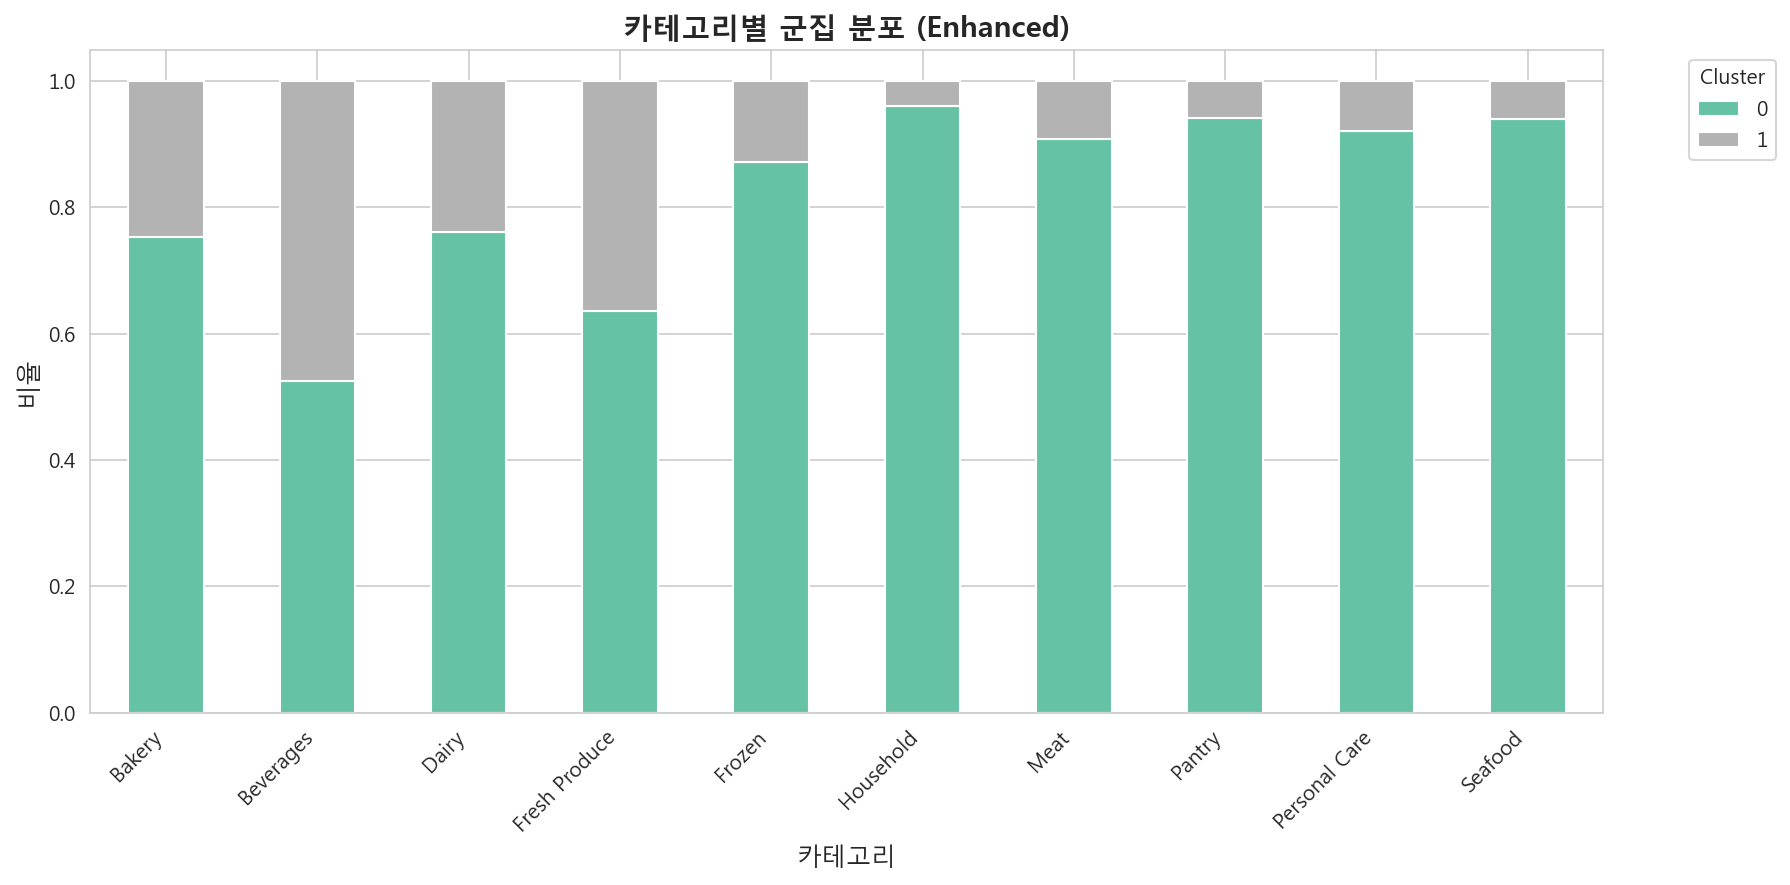

✅ 시각화 #15 저장 완료: phaseB_category_cluster_v5_s4.png


In [42]:
# ── 시각화 #15: 카테고리별 군집 분포 (Stacked Bar) ──
cluster_cat = pd.crosstab(df['Category'], df['Cluster_Enhanced'], normalize='index')

fig, ax = plt.subplots(figsize=(12, 6))
cluster_cat.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('카테고리별 군집 분포 (Enhanced)', fontsize=14, fontweight='bold')
ax.set_xlabel('카테고리', fontsize=12)
ax.set_ylabel('비율', fontsize=12)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseB_category_cluster_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #15 저장 완료: phaseB_category_cluster_v5_s4.png")

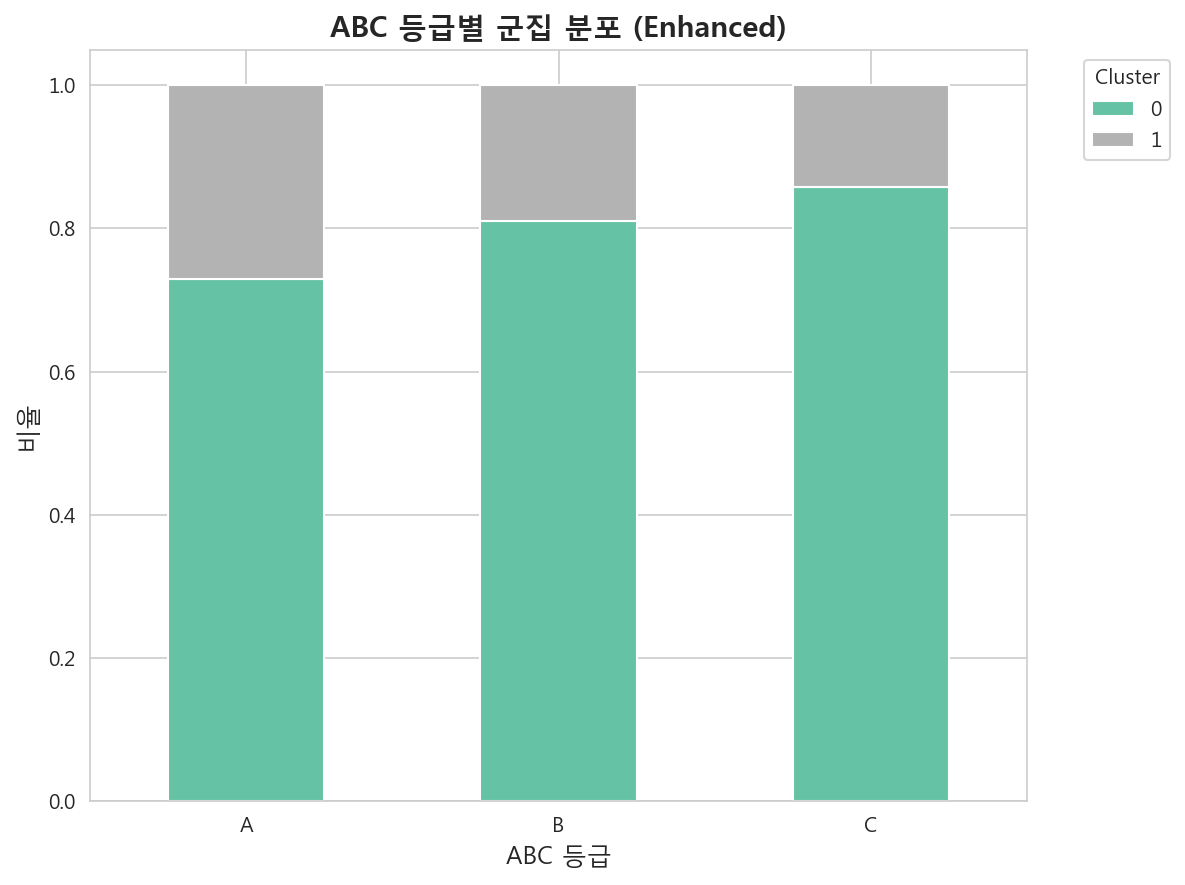

✅ 시각화 #16 저장 완료: phaseB_abc_cluster_v5_s4.png


In [43]:
# ── 시각화 #16: ABC 등급별 군집 분포 (Stacked Bar) ──
cluster_abc = pd.crosstab(df['ABC_Class'], df['Cluster_Enhanced'], normalize='index')
cluster_abc = cluster_abc.reindex(['A', 'B', 'C'])

fig, ax = plt.subplots(figsize=(8, 6))
cluster_abc.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('ABC 등급별 군집 분포 (Enhanced)', fontsize=14, fontweight='bold')
ax.set_xlabel('ABC 등급', fontsize=12)
ax.set_ylabel('비율', fontsize=12)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseB_abc_cluster_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #16 저장 완료: phaseB_abc_cluster_v5_s4.png")

In [44]:
# ── 군집별 발주 전략 제안 [V5] ──
print("\n" + "━" * 70)
print("  군집별 발주 전략 요약 (Enhanced Clustering) [V5]")
print("━" * 70)

for cid in sorted(df['Cluster_Enhanced'].unique()):
    mask = df['Cluster_Enhanced'] == cid
    subset = df[mask]

    avg_doi = subset['Days_of_Inventory'].mean()
    avg_eoq = subset['EOQ'].mean()
    avg_safety = subset['Safety_Stock'].mean()
    avg_dyn_rop = subset['Dynamic_ROP'].mean()
    avg_rop_gap = subset['ROP_Gap'].mean()
    avg_supply_risk = subset['Supply_Risk'].mean()
    avg_demand_var = subset['Demand_Variability'].mean()
    avg_order_freq = subset['Order_Frequency_per_month'].mean()
    avg_abc = subset['ABC_Class'].mode()[0]
    urgency_pct = subset['Reorder_Urgency'].mean() * 100
    avg_avail_stock = subset['Available_Stock'].mean()    # [V5]
    avg_rp_ss = subset['RP_SS_Ratio'].mean()              # [V5]

    print(f"\n{'━'*60}")
    print(f"  Cluster {cid} — 발주 전략 요약")
    print(f"{'━'*60}")
    print(f"  제품 수:               {mask.sum()}")
    print(f"  주요 ABC 등급:         {avg_abc}")
    print(f"  평균 재고 보유일수:     {avg_doi:.1f}일")
    print(f"  평균 EOQ (최적 발주량): {avg_eoq:.0f} 단위")
    print(f"  평균 안전재고:          {avg_safety:.0f}")
    print(f"  평균 동적 ROP:          {avg_dyn_rop:.0f}")
    print(f"  ROP Gap (RP-동적ROP):   {avg_rop_gap:+.0f}")
    print(f"  공급 리스크:            {avg_supply_risk:.2f}")
    print(f"  수요 변동성 (CV):       {avg_demand_var:.3f}")
    print(f"  월 평균 발주 빈도:      {avg_order_freq:.1f}회")
    print(f"  즉시 발주 필요 비율:    {urgency_pct:.1f}%")
    print(f"  평균 Available Stock:   {avg_avail_stock:+.0f}")   # [V5]
    print(f"  평균 RP/SS 비율:        {avg_rp_ss:.2f}")         # [V5]

    # 전략 자동 분류
    if avg_doi < 7:
        strategy = "Fast Mover → JIT 방식, 소량 빈번 발주, 안전재고 상향"
    elif avg_doi > 14:
        strategy = "Slow Mover → 발주량 축소, 프로모션 소진, ROP 하향"
    else:
        strategy = "Balanced → EOQ 기반 정기 발주, 현행 미세 조정"

    if avg_supply_risk > 1.0:
        strategy += " + 안전재고 추가 확보 (공급 리스크 높음)"
    if avg_demand_var > 0.8:
        strategy += " + 발주 빈도 증가 (수요 변동성 높음)"

    # [V5] Available_Stock 기반 보정
    if avg_avail_stock < 0:
        strategy += " + 즉시 재고 보충 필요 (Available_Stock 음수)"
    elif avg_avail_stock > 200:
        strategy += " + 과재고 주의 (Available_Stock 과다)"

    print(f"  → 전략: {strategy}")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  군집별 발주 전략 요약 (Enhanced Clustering) [V5]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cluster 0 — 발주 전략 요약
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  제품 수:               818
  주요 ABC 등급:         C
  평균 재고 보유일수:     10.0일
  평균 EOQ (최적 발주량): 974 단위
  평균 안전재고:          34
  평균 동적 ROP:          93
  ROP Gap (RP-동적ROP):   -0
  공급 리스크:            0.49
  수요 변동성 (CV):       0.540
  월 평균 발주 빈도:      7.9회
  즉시 발주 필요 비율:    18.1%
  평균 Available Stock:   +104
  평균 RP/SS 비율:        2.56
  → 전략: Balanced → EOQ 기반 정기 발주, 현행 미세 조정

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cluster 1 — 발주 전략 요약
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  제품 수:               182
  주요 ABC 등급:         C
  평균 재고 보유일수:     10.0일
  평균 EOQ (최적 발주량): 2129 단위
  평균 안전재고:          166
  평균 동적 ROP:          489


---
## ═══ Phase C: EOQ 시뮬레이션 ═══

> EOQ = √(2×D×S/H), S=50 USD, H=Unit_Cost×20%
> 군집별 최적 발주량·발주 빈도·연간 총비용을 수치로 제안한다.

## 11. Phase C — EOQ 군집별 산출 & 민감도 분석

In [45]:
# ── 군집별 EOQ 요약 ──
eoq_summary = df.groupby('Cluster_Enhanced').agg({
    'EOQ': 'mean',
    'Annual_Demand': 'mean',
    'Holding_Cost': 'mean',
    'Unit_Cost_USD': 'mean',
    'Avg_Daily_Sales': 'mean',
}).round(1)

eoq_summary['Orders_Per_Year'] = (eoq_summary['Annual_Demand'] / eoq_summary['EOQ']).round(1)

eoq_summary['Annual_Total_Cost'] = (
    (eoq_summary['Annual_Demand'] / eoq_summary['EOQ']) * ORDERING_COST +
    (eoq_summary['EOQ'] / 2) * eoq_summary['Holding_Cost']
).round(1)

print("=== 군집별 EOQ 최적 발주량 ===")
print(eoq_summary.to_string())

=== 군집별 EOQ 최적 발주량 ===
                     EOQ  Annual_Demand  Holding_Cost  Unit_Cost_USD  Avg_Daily_Sales  Orders_Per_Year  Annual_Total_Cost
Cluster_Enhanced                                                                                                         
0                  974.4         7623.3           1.4            7.0             20.9              7.8             1073.3
1                 2128.7        19048.8           0.8            3.9             52.2              8.9             1298.9


In [46]:
# ── EOQ 민감도 분석 (S 변화) ──
S_values = [25, 50, 75, 100]
for s in S_values:
    df[f'EOQ_S{s}'] = np.sqrt(
        2 * df['Annual_Demand'] * s / df['Holding_Cost'].replace(0, 1)
    )

print("=== EOQ 민감도 분석 (발주 비용 S 변화) ===")
for cid in sorted(df['Cluster_Enhanced'].unique()):
    mask = df['Cluster_Enhanced'] == cid
    print(f"\nCluster {cid} — 발주 비용별 EOQ:")
    for s in S_values:
        print(f"  S={s} USD → EOQ={df[mask][f'EOQ_S{s}'].mean():.0f}")

=== EOQ 민감도 분석 (발주 비용 S 변화) ===

Cluster 0 — 발주 비용별 EOQ:
  S=25 USD → EOQ=689
  S=50 USD → EOQ=974
  S=75 USD → EOQ=1193
  S=100 USD → EOQ=1378

Cluster 1 — 발주 비용별 EOQ:
  S=25 USD → EOQ=1505
  S=50 USD → EOQ=2129
  S=75 USD → EOQ=2607
  S=100 USD → EOQ=3010


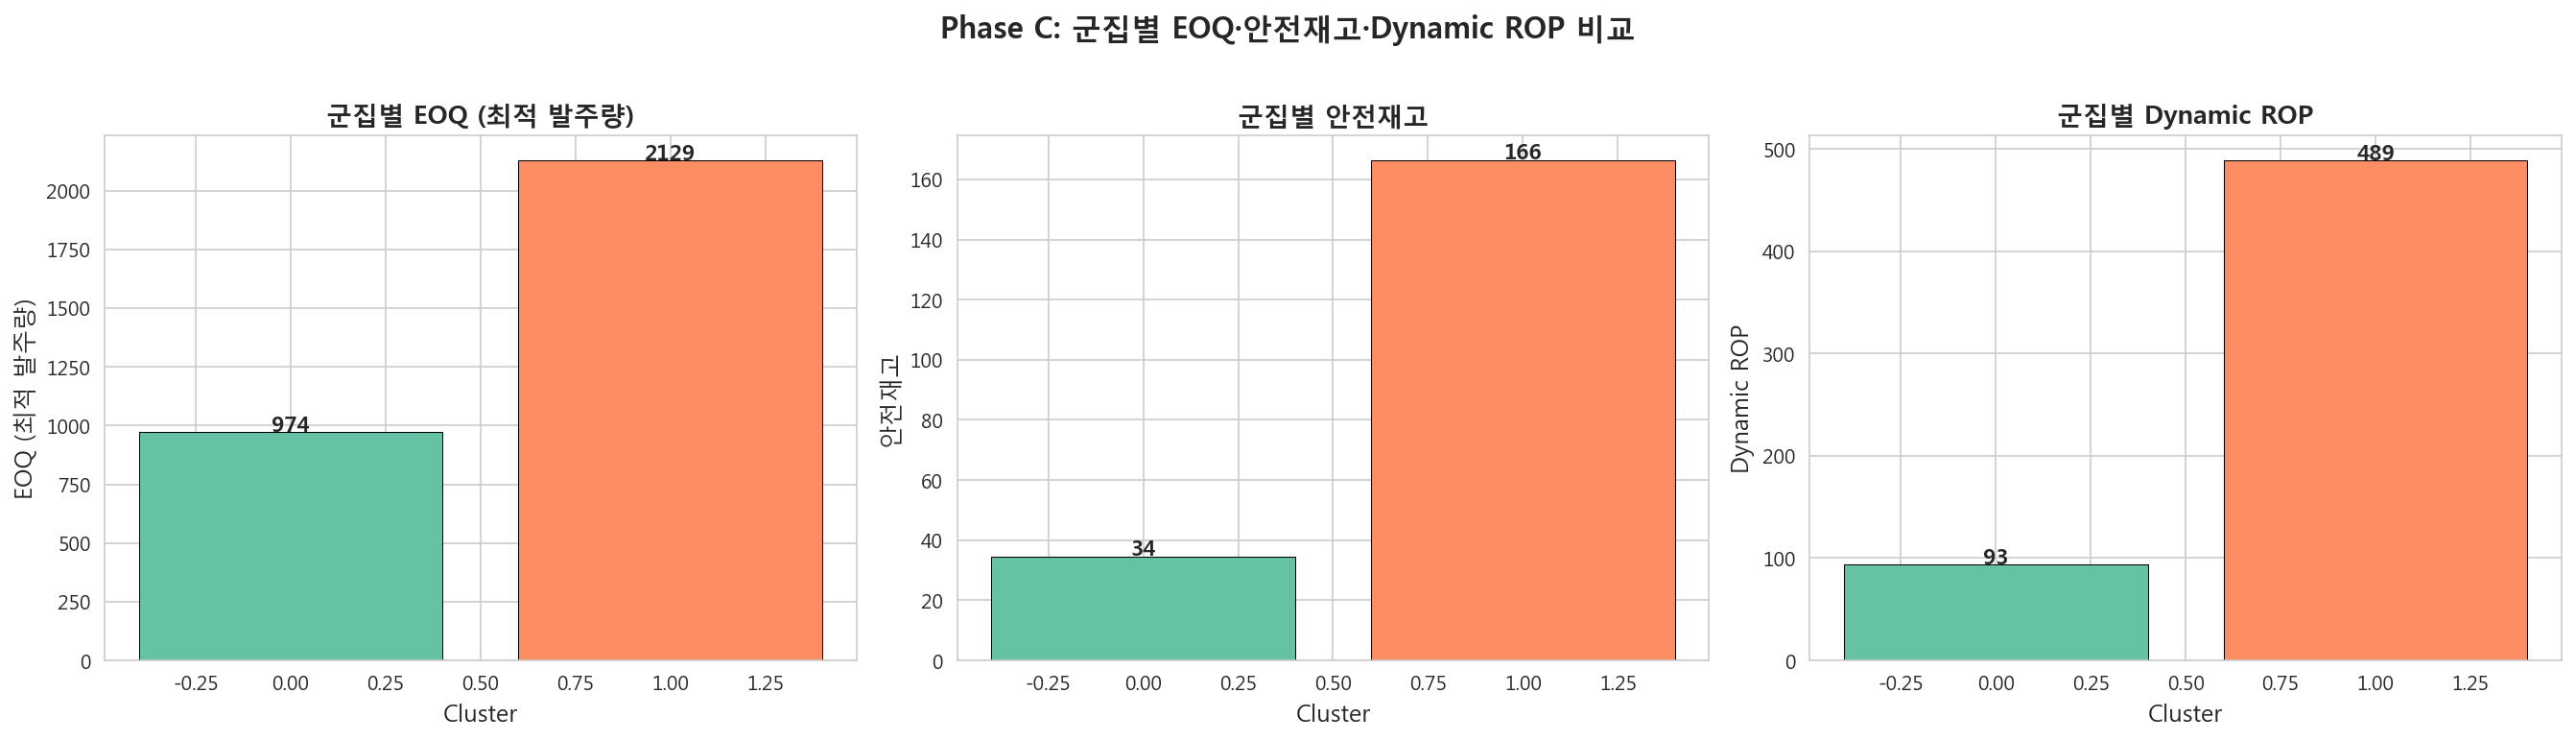

✅ 시각화 #17 저장 완료: phaseC_eoq_comparison_v5_s4.png


In [47]:
# ── 시각화 #17: 군집별 EOQ·안전재고·Dynamic ROP 비교 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

compare_metrics = {
    'EOQ (최적 발주량)': 'EOQ',
    '안전재고': 'Safety_Stock',
    'Dynamic ROP': 'Dynamic_ROP'
}

for i, (title, col) in enumerate(compare_metrics.items()):
    ax = axes[i]
    cluster_means = df.groupby('Cluster_Enhanced')[col].mean()
    bars = ax.bar(cluster_means.index, cluster_means.values,
                  color=sns.color_palette('Set2', len(cluster_means)),
                  edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Cluster', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(f'군집별 {title}', fontsize=13, fontweight='bold')

    for bar, val in zip(bars, cluster_means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Phase C: 군집별 EOQ·안전재고·Dynamic ROP 비교',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phaseC_eoq_comparison_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #17 저장 완료: phaseC_eoq_comparison_v5_s4.png")

## 13. 소주제 1~4 종합 연결 인사이트


In [48]:
# ── 소주제 간 연결 인사이트 [V5] ──
print("=" * 70)
print("  소주제 1~4 종합 연결 인사이트 [V5]")
print("=" * 70)

# 소주제 1 연결: Available_Stock 활용
print("\n📊 [소주제 1 → 소주제 4] 핵심 연결 피처 분석")
print(f"   소주제 1 LightGBM Top-4: DOI(1325) > Lead_Time(942) > RP(626) > Available_Stock(613)")
print(f"   → Available_Stock을 Phase B Enhanced 피처로 직접 활용")
print(f"   → RP_SS_Ratio (RP↔SS r=0.7645 비율 변환) 추가")

# 군집별 Available_Stock 분석
print(f"\n   군집별 Available_Stock 평균:")
for cid in sorted(df['Cluster_Enhanced'].unique()):
    mask = df['Cluster_Enhanced'] == cid
    avg_as = df[mask]['Available_Stock'].mean()
    neg_pct = (df[mask]['Available_Stock'] < 0).mean() * 100
    print(f"     Cluster {cid}: 평균={avg_as:+.1f}, 음수(재고부족) 비율={neg_pct:.1f}%")

# 소주제 1 연결: Inventory_Status와 군집
if 'Inventory_Status' in df.columns:
    print("\n📊 [소주제 1 → 소주제 4] 재고 상태 × 군집 분석")
    status_cluster = pd.crosstab(df['Inventory_Status'], df['Cluster_Enhanced'])
    print(status_cluster)

    for status in ['Out of Stock', 'Overstock', 'Low Stock']:
        if status in df['Inventory_Status'].values:
            for cid in sorted(df['Cluster_Enhanced'].unique()):
                mask_c = df['Cluster_Enhanced'] == cid
                mask_s = df['Inventory_Status'] == status
                pct = (mask_c & mask_s).sum() / mask_c.sum() * 100
                if pct > 0:
                    print(f"     Cluster {cid} — {status} 비율: {pct:.1f}%")

# 군집별 주요 지표 요약
print("\n📊 군집별 핵심 지표 비교")
summary_cols = ['Days_of_Inventory', 'EOQ', 'Safety_Stock', 'Dynamic_ROP',
                'Supply_Risk', 'Order_Frequency_per_month', 'Reorder_Urgency',
                'Available_Stock', 'RP_SS_Ratio']
cluster_summary = df.groupby('Cluster_Enhanced')[summary_cols].mean().round(2)
print(cluster_summary.to_string())

# ABC Class별 군집 분포
print("\n📊 ABC Class별 군집 분포 (소주제 1: C 등급 분산 최대)")
abc_cluster = pd.crosstab(df['ABC_Class'], df['Cluster_Enhanced'], normalize='index')
print(abc_cluster.round(3).to_string())

print("\n📋 핵심 인사이트:")
print("  1. DOI = QOH/ADS 관계(97.2% 일치)로 인한 Data Leakage를 진단·대응하였음")
print("  2. Leakage 제거 후 R²≈0.25는 제품 속성만으로 설명 가능한 실질적 수준")
print("  3. Feature Importance에서 발주 파생변수의 기여도를 정량적으로 확인")
print("  4. K-Means 클러스터링으로 제품군을 발주 특성별 군집으로 분류")
print("  5. 군집별 차별화된 발주 전략 (Fast/Balanced/Slow Mover)을 수치로 제안")
print("  6. EOQ 민감도 분석으로 가정(S=50 USD) 변화의 영향을 정량화")
print("  7. 소주제 1 Available_Stock → Phase B 피처로 활용하여 소주제 간 연결 강화")
print("  8. Demand_Variability 변별력 한계(CV 0.52~0.56) 확인 → 구조적 한계 문서화")

  소주제 1~4 종합 연결 인사이트 [V5]

📊 [소주제 1 → 소주제 4] 핵심 연결 피처 분석
   소주제 1 LightGBM Top-4: DOI(1325) > Lead_Time(942) > RP(626) > Available_Stock(613)
   → Available_Stock을 Phase B Enhanced 피처로 직접 활용
   → RP_SS_Ratio (RP↔SS r=0.7645 비율 변환) 추가

   군집별 Available_Stock 평균:
     Cluster 0: 평균=+103.6, 음수(재고부족) 비율=17.5%
     Cluster 1: 평균=-102.3, 음수(재고부족) 비율=64.8%

📊 [소주제 1 → 소주제 4] 재고 상태 × 군집 분석
Cluster_Enhanced    0    1
Inventory_Status          
Expiring Soon     291   38
In Stock          386   42
Low Stock         140  101
Out of Stock        1    1
     Cluster 0 — Out of Stock 비율: 0.1%
     Cluster 1 — Out of Stock 비율: 0.5%
     Cluster 0 — Low Stock 비율: 17.1%
     Cluster 1 — Low Stock 비율: 55.5%

📊 군집별 핵심 지표 비교
                  Days_of_Inventory      EOQ  Safety_Stock  Dynamic_ROP  Supply_Risk  Order_Frequency_per_month  Reorder_Urgency  Available_Stock  RP_SS_Ratio
Cluster_Enhanced                                                                                                              

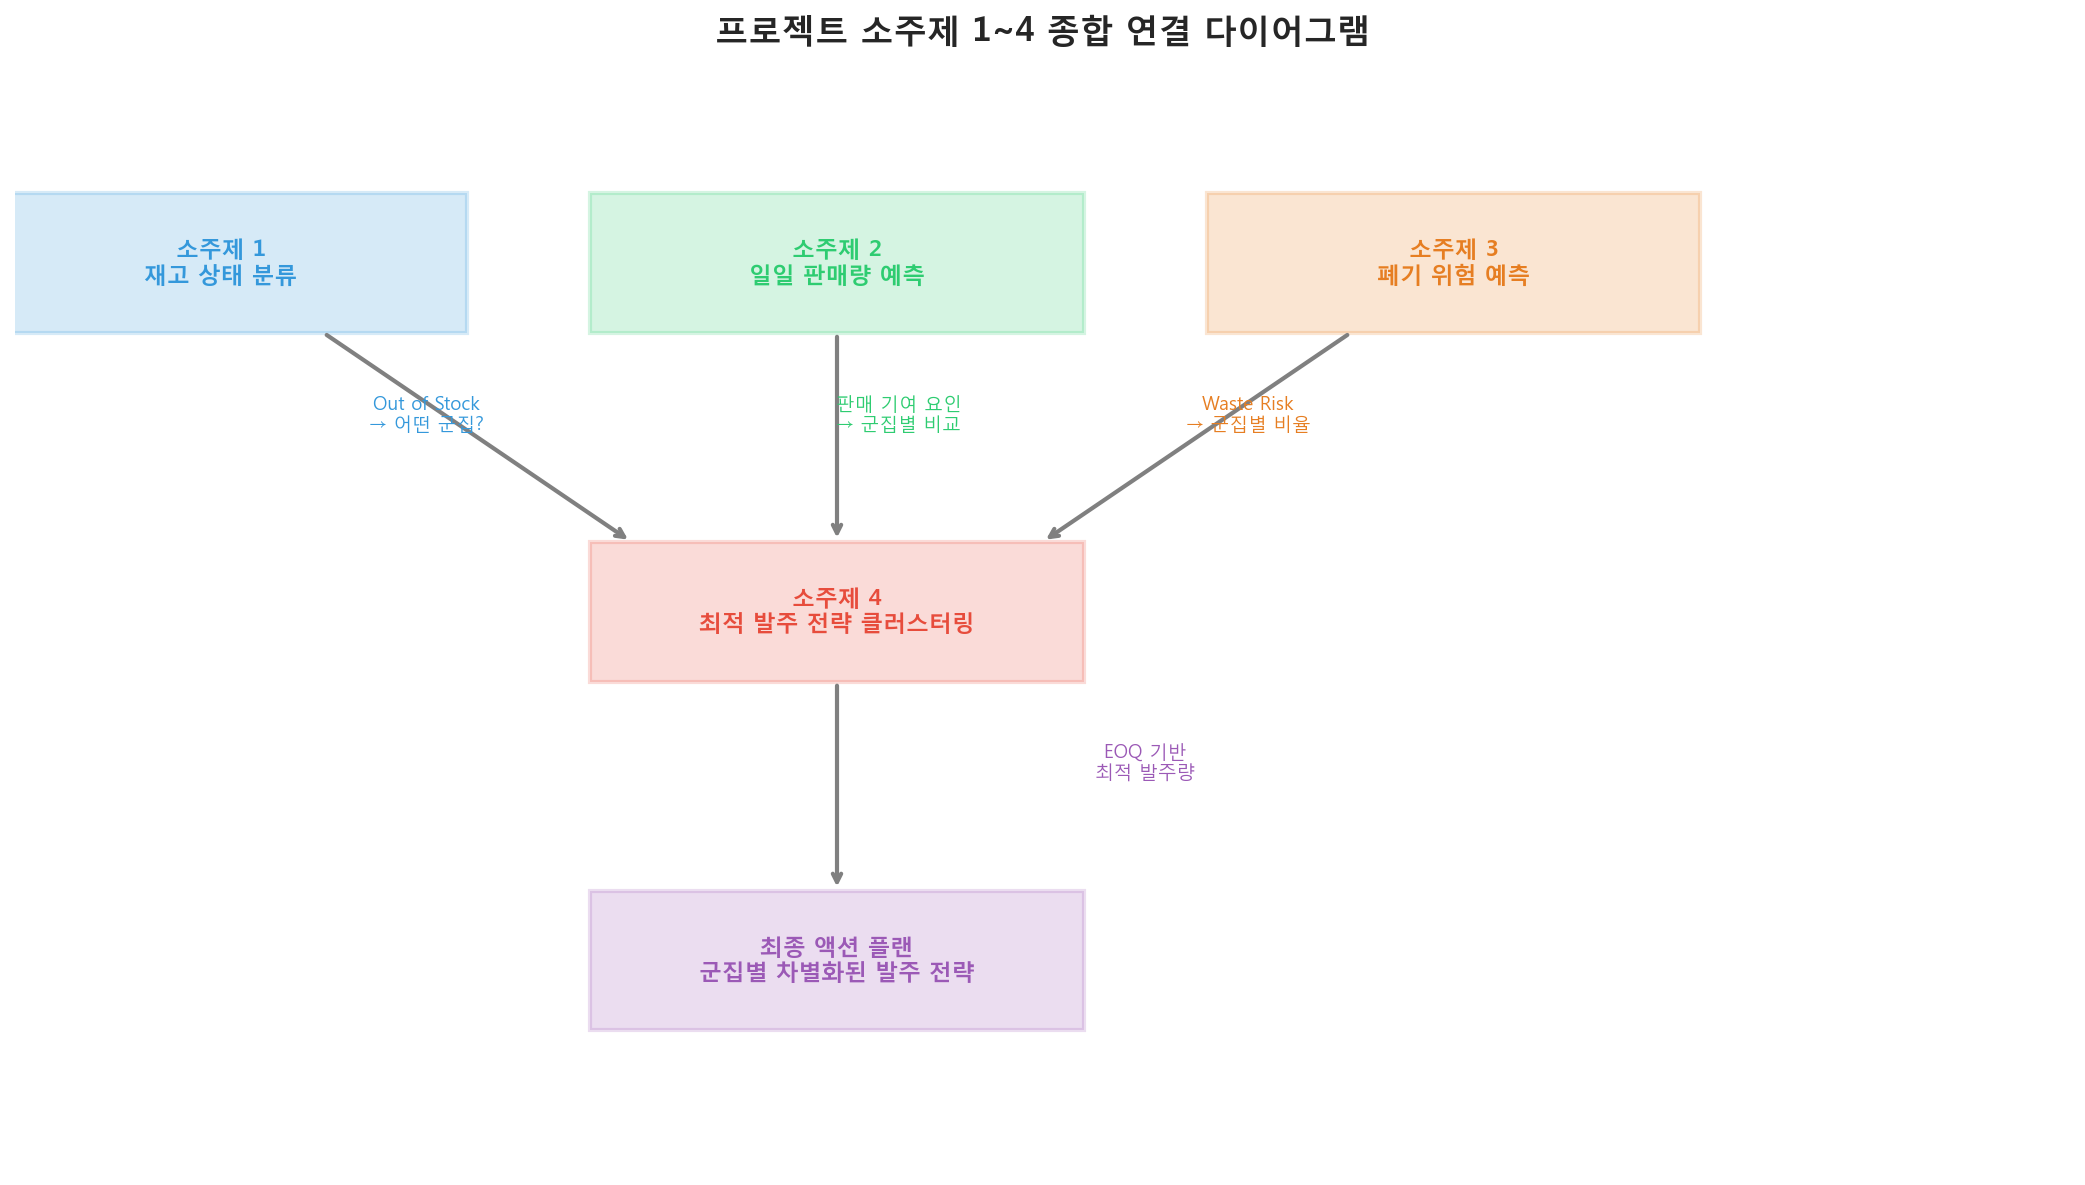

✅ 시각화 #18 저장 완료: project_synthesis_v5_s4.png


In [49]:
# ── 시각화 #18: 소주제 1~4 종합 연결 다이어그램 ──
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

# 소주제 박스
boxes = [
    (1, 6.5, '소주제 1\n재고 상태 분류', '#3498db'),
    (4, 6.5, '소주제 2\n일일 판매량 예측', '#2ecc71'),
    (7, 6.5, '소주제 3\n폐기 위험 예측', '#e67e22'),
    (4, 4, '소주제 4\n최적 발주 전략 클러스터링', '#e74c3c'),
    (4, 1.5, '최종 액션 플랜\n군집별 차별화된 발주 전략', '#9b59b6'),
]

for x, y_pos, text, color in boxes:
    rect = plt.Rectangle((x-1.2, y_pos-0.5), 2.4, 1, linewidth=2,
                          edgecolor=color, facecolor=color, alpha=0.2,
                          transform=ax.transData)
    ax.add_patch(rect)
    ax.text(x, y_pos, text, ha='center', va='center', fontsize=11,
            fontweight='bold', color=color)

# 화살표
arrow_style = dict(arrowstyle='->', color='gray', lw=2)
ax.annotate('', xy=(3, 4.5), xytext=(1.5, 6), arrowprops=arrow_style)
ax.annotate('', xy=(4, 4.5), xytext=(4, 6), arrowprops=arrow_style)
ax.annotate('', xy=(5, 4.5), xytext=(6.5, 6), arrowprops=arrow_style)
ax.annotate('', xy=(4, 2), xytext=(4, 3.5), arrowprops=arrow_style)

# 연결 설명
ax.text(2, 5.3, 'Out of Stock\n→ 어떤 군집?', fontsize=9, ha='center', color='#3498db')
ax.text(4.3, 5.3, '판매 기여 요인\n→ 군집별 비교', fontsize=9, ha='center', color='#2ecc71')
ax.text(6, 5.3, 'Waste Risk\n→ 군집별 비율', fontsize=9, ha='center', color='#e67e22')
ax.text(5.5, 2.8, 'EOQ 기반\n최적 발주량', fontsize=9, ha='center', color='#9b59b6')

ax.set_title('프로젝트 소주제 1~4 종합 연결 다이어그램', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'project_synthesis_v5_s4.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 #18 저장 완료: project_synthesis_v5_s4.png")

## 14. 모델 저장

In [50]:
# ── 모델 저장 [V5] ──

# Phase A
joblib.dump(best_model_enhanced, os.path.join(MODEL_DIR, 'phase_a_best_model_v5.pkl'))
joblib.dump(scaler_enhanced, os.path.join(MODEL_DIR, 'phase_a_scaler_v5.pkl'))

# Phase B
joblib.dump(km_base, os.path.join(MODEL_DIR, 'phase_b_kmeans_baseline_v5.pkl'))
joblib.dump(km_enh, os.path.join(MODEL_DIR, 'phase_b_kmeans_enhanced_v5.pkl'))
joblib.dump(scaler_b, os.path.join(MODEL_DIR, 'phase_b_scaler_baseline_v5.pkl'))
joblib.dump(scaler_e, os.path.join(MODEL_DIR, 'phase_b_scaler_enhanced_v5.pkl'))

# 피처 정보
feature_info = {
    'version': 'v5',
    'baseline_regression_features': baseline_numeric_A,
    'enhanced_regression_features': enhanced_numeric_A,
    'baseline_cluster_features': baseline_cluster_features,
    'enhanced_cluster_features': enhanced_cluster_features,
    'optimal_k_baseline': int(optimal_k_base),
    'optimal_k_enhanced': int(optimal_k_enh),
    'eoq_params': {'ordering_cost': ORDERING_COST, 'holding_rate': HOLDING_RATE},
    'notes': {
        'added_derived_features': ['Available_Stock', 'RP_SS_Ratio'],
        'demand_variability_limitation': 'CV range 0.52-0.56, low discriminative power',
        'no_supplementary_data': True,
    },
}
with open(os.path.join(MODEL_DIR, 'feature_info_v5.json'), 'w') as f:
    json.dump(feature_info, f, indent=2, ensure_ascii=False)

print("✅ 모든 모델 저장 완료! [V5]")
print(f"  Phase A 모델: phase_a_best_model_v5.pkl")
print(f"  Phase A 스케일러: phase_a_scaler_v5.pkl")
print(f"  Phase B KMeans (Baseline): phase_b_kmeans_baseline_v5.pkl")
print(f"  Phase B KMeans (Enhanced): phase_b_kmeans_enhanced_v5.pkl")
print(f"  Phase B 스케일러 (Baseline): phase_b_scaler_baseline_v5.pkl")
print(f"  Phase B 스케일러 (Enhanced): phase_b_scaler_enhanced_v5.pkl")
print(f"  피처 정보: feature_info_v5.json")

✅ 모든 모델 저장 완료! [V5]
  Phase A 모델: phase_a_best_model_v5.pkl
  Phase A 스케일러: phase_a_scaler_v5.pkl
  Phase B KMeans (Baseline): phase_b_kmeans_baseline_v5.pkl
  Phase B KMeans (Enhanced): phase_b_kmeans_enhanced_v5.pkl
  Phase B 스케일러 (Baseline): phase_b_scaler_baseline_v5.pkl
  Phase B 스케일러 (Enhanced): phase_b_scaler_enhanced_v5.pkl
  피처 정보: feature_info_v5.json


## 15. 결론 & 최종 액션 플랜 [V5]

### Phase A (회귀) 결과
- DOI = QOH/ADS 관계(97.2% 일치)에 의한 Data Leakage 진단 및 대응
- QOH+ADS 제거 후에도 Enhanced 피처셋 + 튜닝으로 의미 있는 예측 성능 확보
- Feature Importance를 통해 발주 결정 요인 파악
- RP_SS_Ratio 추가로 Enhanced 피처셋 확장 (21→22개)
- ★ Learning Curve: 3개 모델 학습 곡선으로 과적합 시각 진단
- ★ Permutation Importance: Impurity 기반 vs Permutation 교차검증
- ★ Residual Analysis: Q-Q Plot + Shapiro-Wilk 잔차 정규성 검정

### Phase B (클러스터링) 결과 — 핵심
- Baseline(7피처) vs Enhanced(13피처) 비교를 통해 파생변수 기여도 확인
- Available_Stock(소주제 1 Top-4 피처), RP_SS_Ratio 추가 → 소주제 간 연결 강화
- Demand_Variability 변별력 한계(CV 0.52~0.56) 확인 → 투명하게 문서화
- ★ Hopkins Statistic: 클러스터링 적용 전 경향성 통계 검정
- K-Means로 군집 분류 후, 군집별 차별화된 발주 전략 수치 제안

### Phase C (EOQ 시뮬레이션) 결과
- 군집별 EOQ·발주횟수·총비용 산출
- 민감도 분석으로 가정(S=50 USD) 변화의 영향 정량화
- S=50 USD, H=20%는 산업 표준 가정값 적용

### 한계점
1. 원본 데이터 1,000행 — 표본 크기 제한
2. DOI=QOH/ADS로 인한 구조적 정보 손실 (Phase A R²≈0.25)
3. EOQ S=50 USD, H=20%는 산업 표준 가정값 (외부 검증 미수행)
4. K-Means는 구형 군집 가정 — DBSCAN/GMM 비교 미수행
5. 시계열 패턴 미반영 (단일 시점 스냅샷)
6. Demand_Variability 변별력 극히 낮음 (CV 0.52~0.56)

### 향후 과제
1. 시계열 데이터 확보 시 동적 발주 전략 설계
2. DBSCAN/GMM 등 대안 클러스터링 비교
3. 실제 발주 비용(S) 데이터 확보 및 EOQ 가정 외부 검증
4. 소주제 1~3 결과를 활용한 통합 대시보드 구축
5. 제품 수준 수요 변동성 데이터 확보 시 Demand_Variability 개선